In [ ]:
""" 
This notebook will implement k-mean clustering model on WIM data using axle loads
to produce groups empty, partially empty, and full vehicles

"""

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Capstone_Data") \
    .master("local[*]") \
    .getOrCreate()


In [2]:
#historical dataset 2019 - 2023
df = spark.read.csv("Data\Raw_Data\Weigh_in_Motion_19_23.csv", header=True, inferSchema=True)

<>:2: SyntaxWarning: invalid escape sequence '\R'
<>:2: SyntaxWarning: invalid escape sequence '\R'
C:\Users\rubie\AppData\Local\Temp\ipykernel_1204\3529866632.py:2: SyntaxWarning: invalid escape sequence '\R'
  df = spark.read.csv("Data\Raw_Data\Weigh_in_Motion_19_23.csv", header=True, inferSchema=True)


In [3]:
df2 = spark.read.csv("Data\Raw_Data\Weigh_in_Motion_24_25.csv", header=True, inferSchema=True)

<>:1: SyntaxWarning: invalid escape sequence '\R'
<>:1: SyntaxWarning: invalid escape sequence '\R'
C:\Users\rubie\AppData\Local\Temp\ipykernel_1204\3059976666.py:1: SyntaxWarning: invalid escape sequence '\R'
  df2 = spark.read.csv("Data\Raw_Data\Weigh_in_Motion_24_25.csv", header=True, inferSchema=True)


In [4]:
#aggregating both datasets into 1
df3 = df.union(df2)

In [5]:
#Creating a date column
from pyspark.sql.functions import col, concat, lpad
df4 = df3.withColumn(
    "date",
    concat(
        col("year"),
        lpad(col("month"), 2, "0"),  
        lpad(col("day"), 2, "0")
    )
)


In [6]:
#Filtering for QueensBound Data and casting gvw column as float type
from pyspark.sql import functions as F

df5 = df4.filter("direction = 'QB'").withColumn("gvw", F.col("gvw").cast("float"))

In [7]:
df5 = df5.fillna(0)

In [8]:
# Removing outliers *asssume pandas df, targets gvw col
def remove_outliers_iqr(df, factor):
    Q1 = df["gvw"].quantile(0.25)
    Q3 = df["gvw"].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR

    outliers_iqr = df[(df["gvw"] < lower_bound) | (df["gvw"] > upper_bound)]
    
    print(f"Outlier Count: {len(outliers_iqr)}")
    print(f"Original Count: {len(df)}")
    print(f"Remaining count: {len(df) - len(outliers_iqr)}")
    print(f"Outlier percentage: {len(outliers_iqr)/len(df)*100:.2f}%")
    print(f"Upper bound: {upper_bound:.2f}, Lower bound: {lower_bound:.2f}")
    
    # Return filtered dataframe
    return df[(df["gvw"] >= lower_bound) & (df["gvw"] <= upper_bound)], upper_bound, lower_bound

In [9]:
#eliminate outliers from spark df
from pyspark.sql import functions as F

def remove_outliers_iqr2(df_spark, col_name, factor):
    # Step 1: Get Q1 and Q3
    q1, q3 = df_spark.approxQuantile(col_name, [0.25, 0.75], 0.01)

    # Step 2: Compute IQR
    iqr = q3 - q1

    # Step 3: Define bounds
    lower_bound = q1 - factor * iqr
    upper_bound = q3 + factor * iqr

    print(f"Upper bound: {upper_bound}, Lower bound: {lower_bound}")

    # Step 4: Filter outliers
    return df_spark.filter((F.col(col_name) >= lower_bound) & (F.col(col_name) <= upper_bound)) , upper_bound, lower_bound

In [10]:
#K-mean clustering model
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import ClusteringEvaluator

#function expects spark df
def kmeans_model_spark(df_spark, feature_cols, num_clusters, n_init=None, sample_fraction=1.0):
    from pyspark.ml.clustering import KMeans
    from pyspark.ml.feature import VectorAssembler
    from pyspark.ml.evaluation import ClusteringEvaluator

    assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
    df_vector = assembler.transform(df_spark)

    # Fit model
    kmeans = KMeans().setK(num_clusters).setFeaturesCol("features")
    
    if n_init != None:
        kmeans = kmeans.setInitSteps(n_init)

    model = kmeans.fit(df_vector)

    # Predict
    predictions = model.transform(df_vector)

    # --- Sample for silhouette computation ---
    if sample_fraction < 1.0:
        predictions_sample = predictions.sample(withReplacement=False, fraction=sample_fraction)
    else:
        predictions_sample = predictions

    evaluator = ClusteringEvaluator()
    silhouette = evaluator.evaluate(predictions_sample)

    centers = model.clusterCenters()

    return {
        "silhouette": silhouette,
        "centers": centers,
        "num_clusters": num_clusters
    }

    

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

def kmeans_model_pandas(df, feature_cols, num_clusters=2, n_init_var=10):
    # Extract feature matrix
    X = df[feature_cols].values

    # Initialize and fit KMeans
    kmeans = KMeans(n_clusters=num_clusters, n_init=n_init_var)
    labels = kmeans.fit_predict(X)

    # Calculate number of unique clusters found
    n_clusters_found = len(np.unique(labels))

    if n_clusters_found > 1:  
        try:
            silhouette = silhouette_score(X, labels, sample_size=1000)
            print(silhouette)
            print(n_clusters_found)
        except ValueError:
            silhouette = np.nan
    else:
        silhouette = np.nan

    return {
        "centers": kmeans.cluster_centers_,
        "labels": labels,
        "silhouette": silhouette,
        "n_clusters_found": n_clusters_found,
        "n_clusters_requested": num_clusters,
    }



In [65]:
#function for checking stability of model results based on n_init parameter
def tune_n_init(df, cols, n_init):
    try:
        result2 = kmeans_model_pandas(df, cols, 2, n_init)
        result3 = kmeans_model_pandas(df, cols, 3, n_init)
        
        # Check if we actually got the expected number of clusters
        if result2["n_clusters_found"] < 2:
            print(f"Warning: n_init={n_init}, k=2: Only {result2['n_clusters_found']} cluster(s) found")
            sil2 = np.nan
        else:
            sil2 = result2["silhouette"]
            
        if result3["n_clusters_found"] < 2:
            print(f"Warning: n_init={n_init}, k=3: Only {result3['n_clusters_found']} cluster(s) found")
            sil3 = np.nan
        else:
            sil3 = result3["silhouette"]
            
        return (n_init, sil2, sil3)
        
    except Exception as e:
        print(f"Error with n_init={n_init}: {e}")
        return (n_init, np.nan, np.nan)

Class 2

In [292]:
import pandas as pd
#filtering by class
class_num = 2
sample_ratio = .01
cols = [f"wt{i}" for i in range(1, 6)]

df_spark = df5.filter(f"class = {class_num}")

In [293]:
df_spark.select("num_axles").distinct().collect() 

[Row(num_axles=3), Row(num_axles=4), Row(num_axles=2), Row(num_axles=5)]

In [294]:
#Sample original dataset
df_sample = df5.filter(f"class = {class_num}").sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

print(f"Number of records {df_sample.count()}")
print(f"Number of records sampled {df_sample.count()*sample_ratio}")

Number of records direction    636884
year         636884
month        636884
day          636884
hour         636884
minute       636884
second       636884
lane         636884
class        636884
speed        636884
num_axles    636884
gvw          636884
wheelbase    636884
wt1          636884
spc1         636884
wt2          636884
spc2         636884
wt3          636884
spc3         636884
wt4          636884
spc4         636884
wt5          636884
spc5         636884
wt6          636884
spc6         636884
wt7          636884
spc7         636884
wt8          636884
spc8         636884
wt9          636884
spc9         636884
wt10         636884
spc10        636884
wt11         636884
spc11        636884
wt12         636884
spc12        636884
wt13         636884
spc13        636884
wt14         636884
spc14        636884
wt15         636884
spc15        636884
wt16         636884
spc16        636884
wt17         636884
dirtravel    636884
yearmonth    636884
date         636884
dt

In [295]:
#Removing outliers from df_sample, removes outliers based off gvw col
iqr_factor = 1.6
df_sample2, upper_bound, lower_bound = remove_outliers_iqr(df_sample, iqr_factor)

#decreased bound size

Outlier Count: 9737
Original Count: 636884
Remaining count: 627147
Outlier percentage: 1.53%
Upper bound: 6648.00, Lower bound: 222.00


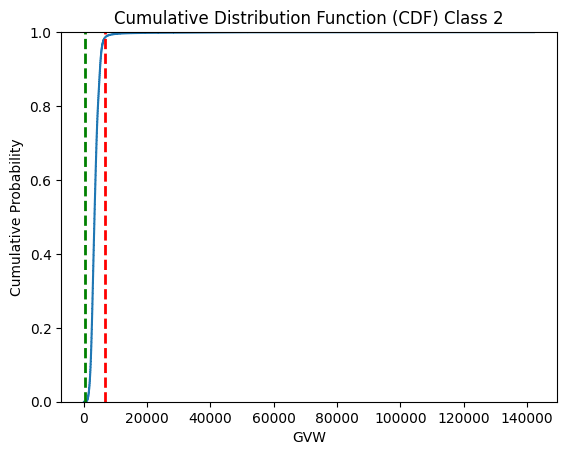

In [296]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.ecdfplot(data=df_sample["gvw"])
plt.title(f'Cumulative Distribution Function (CDF) Class {class_num}')
plt.xlabel('GVW')
plt.ylabel('Cumulative Probability')

plt.axvline(x=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper Bound = {upper_bound}')
plt.axvline(x=lower_bound, color='green', linestyle='--', linewidth=2, label=f'Lower Bound = {lower_bound}')

plt.show()

In [297]:
#Sub-sample for model parameter tuning
sample_size = 10000
tuning_sample_df = df_sample2.sample(sample_size)

In [298]:
#mean , variance similar to complete dataset stats
tuning_sample_df["gvw"].describe()

count    10000.000000
mean      3468.491943
std       1104.715210
min        550.000000
25%       2660.000000
50%       3360.000000
75%       4190.000000
max       6640.000000
Name: gvw, dtype: float64

In [299]:
#Tuning Kmeans n_init parameter for stability
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

silo_scores_n2 = []
silo_scores_n3 = []
number_of_trials = 50

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_n_init)(tuning_sample_df, cols, n) 
    for n in range(1, number_of_trials+1)
)

# Results are returned in order
for n_init, s2, s3 in results:
    silo_scores_n2.append(s2)
    silo_scores_n3.append(s3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    2.6s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:    2.9s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:    3.0s
[Parallel(n_jobs=15)]: Done  27 out of  50 | elapsed:    3.3s remaining:    2.8s
[Parallel(n_jobs=15)]: Done  33 out of  50 | elapsed:    3.5s remaining:    1.7s
[Parallel(n_jobs=15)]: Done  39 out of  50 | elapsed:    3.6s remaining:    0.9s
[Parallel(n_jobs=15)]: Done  45 out of  50 | elapsed:    3.9s remaining:    0.3s
[Parallel(n_jobs=15)]: Done  50 out of  50 | elapsed:    4.0s finished


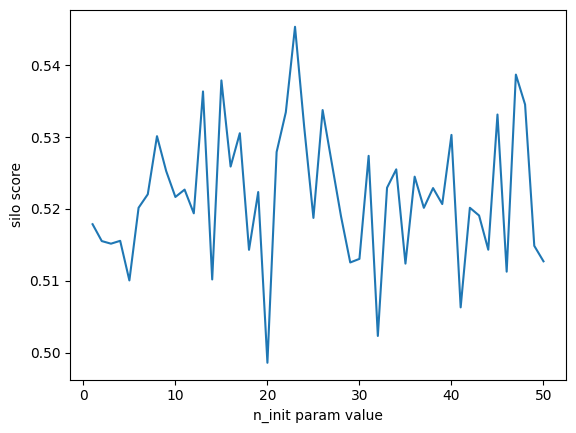

In [300]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,51), silo_scores_n2)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

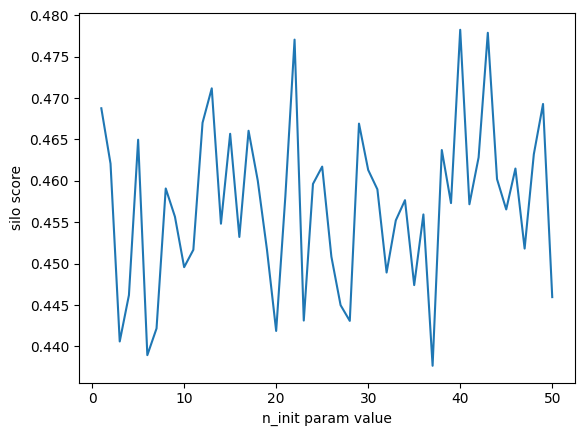

In [301]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,51), silo_scores_n3)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

In [302]:
#remove outliers from sparkdf
df_no_outliers, upper_bound, lower_bound = remove_outliers_iqr2(df_spark, "gvw", iqr_factor)

Upper bound: 6664.0, Lower bound: 196.0


In [303]:
#Comparing if 2 clusters performs better then 3
cluster_num = 2
n_init_param_cluster2 = 20
number_of_trials = 100
sample_means_silo_scores_n2= [] #sample means cluster num=2

import gc
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 2
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster2) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n2.append(np.mean(silo_score)) #for cluster num = 2
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [304]:
#Comparing if 2 clusters performs better then 3
cluster_num = 3
n_init_param_cluster3 = 20
number_of_trials = 100
sample_means_silo_scores_n3= [] #sample means cluster num = 3

import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 3
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster3) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n3.append(np.mean(silo_score)) #for cluster num = 3
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [305]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(sample_means_silo_scores_n2, sample_means_silo_scores_n3)

print(f"Cluster=2 mean: {np.mean(sample_means_silo_scores_n2):.2f}")
print(f"Cluster=3 mean: {np.mean(sample_means_silo_scores_n3):.2f}")
print(f"Mean difference: {np.mean(sample_means_silo_scores_n3) - np.mean(sample_means_silo_scores_n2):.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

Cluster=2 mean: 0.50
Cluster=3 mean: 0.50
Mean difference: 0.01
T-statistic: -51.324
P-value: 0.0000


In [306]:
print(np.var(sample_means_silo_scores_n2)) 
print(np.var(sample_means_silo_scores_n3))

7.872700543791838e-07
6.464257602454234e-07


In [307]:
#Cluster 2
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 2,n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1

0.6986731652555118

In [308]:
#Cluster 3
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 3, n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1


0.6342954190541996

Class 3

In [309]:
import pandas as pd
#filtering by class
class_num = 3
sample_ratio = .01
cols =  [f"wt{i}" for i in range(1, 6)]

df_spark = df5.filter(f"class = {class_num}")

In [310]:
df_spark.select("num_axles").distinct().collect() 

[Row(num_axles=3), Row(num_axles=5), Row(num_axles=4), Row(num_axles=2)]

In [311]:
#Sample original dataset
df_sample = df5.filter(f"class = {class_num}").sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

print(f"Number of records {df_sample.count()}")
print(f"Number of records sampled {df_sample.count()*sample_ratio}")

Number of records direction    102108
year         102108
month        102108
day          102108
hour         102108
minute       102108
second       102108
lane         102108
class        102108
speed        102108
num_axles    102108
gvw          102108
wheelbase    102108
wt1          102108
spc1         102108
wt2          102108
spc2         102108
wt3          102108
spc3         102108
wt4          102108
spc4         102108
wt5          102108
spc5         102108
wt6          102108
spc6         102108
wt7          102108
spc7         102108
wt8          102108
spc8         102108
wt9          102108
spc9         102108
wt10         102108
spc10        102108
wt11         102108
spc11        102108
wt12         102108
spc12        102108
wt13         102108
spc13        102108
wt14         102108
spc14        102108
wt15         102108
spc15        102108
wt16         102108
spc16        102108
wt17         102108
dirtravel    102108
yearmonth    102108
date         102108
dt

In [312]:
#Removing outliers from df_sample, removes outliers based off gvw col
iqr_factor = 2.5
df_sample2, upper_bound, lower_bound = remove_outliers_iqr(df_sample, iqr_factor)

#decreased bound size

Outlier Count: 1568
Original Count: 102108
Remaining count: 100540
Outlier percentage: 1.54%
Upper bound: 12835.00, Lower bound: -1985.00


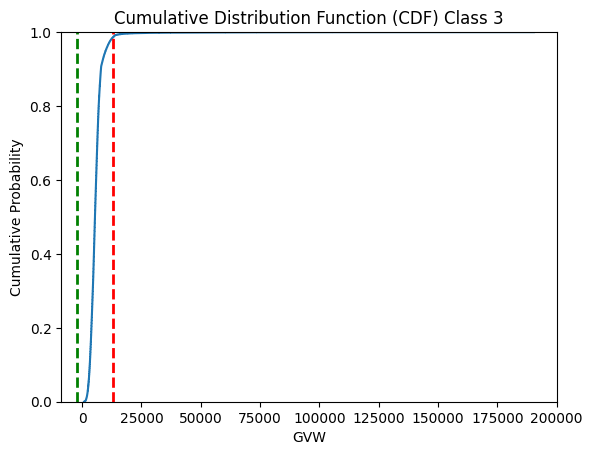

In [313]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.ecdfplot(data=df_sample["gvw"])
plt.title(f'Cumulative Distribution Function (CDF) Class {class_num}')
plt.xlabel('GVW')
plt.ylabel('Cumulative Probability')

plt.axvline(x=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper Bound = {upper_bound}')
plt.axvline(x=lower_bound, color='green', linestyle='--', linewidth=2, label=f'Lower Bound = {lower_bound}')

plt.show()

In [314]:
#Sub-sample for model parameter tuning
sample_size = 10000
tuning_sample_df = df_sample2.sample(sample_size)

In [315]:
#mean , variance similar to complete dataset stats
tuning_sample_df["gvw"].describe()

count    10000.000000
mean      5513.815430
std       1944.183838
min        800.000000
25%       4160.000000
50%       5360.000000
75%       6580.000000
max      12820.000000
Name: gvw, dtype: float64

In [316]:
#Tuning Kmeans n_init parameter for stability
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

silo_scores_n2 = []
silo_scores_n3 = []
number_of_trials = 50

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_n_init)(tuning_sample_df, cols, n) 
    for n in range(1, number_of_trials+1)
)

# Results are returned in order
for n_init, s2, s3 in results:
    silo_scores_n2.append(s2)
    silo_scores_n3.append(s3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    2.7s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:    2.9s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:    3.1s
[Parallel(n_jobs=15)]: Done  27 out of  50 | elapsed:    3.3s remaining:    2.8s
[Parallel(n_jobs=15)]: Done  33 out of  50 | elapsed:    3.5s remaining:    1.7s
[Parallel(n_jobs=15)]: Done  39 out of  50 | elapsed:    3.7s remaining:    1.0s
[Parallel(n_jobs=15)]: Done  45 out of  50 | elapsed:    3.9s remaining:    0.3s
[Parallel(n_jobs=15)]: Done  50 out of  50 | elapsed:    4.0s finished


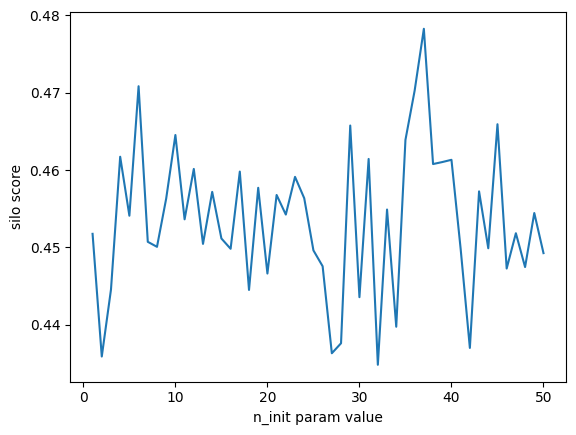

In [317]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,51), silo_scores_n2)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

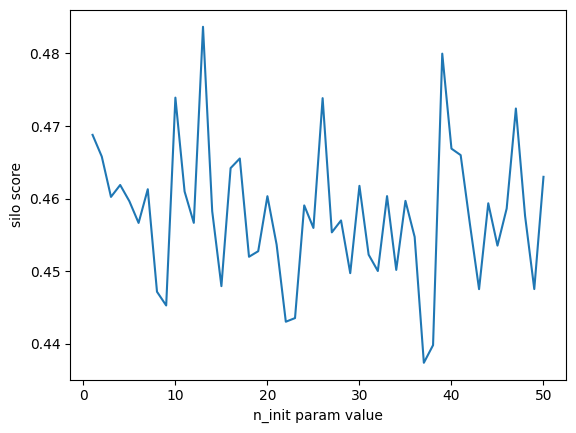

In [318]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,51), silo_scores_n3)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

In [319]:
#remove outliers from sparkdf
df_no_outliers, upper_bound, lower_bound = remove_outliers_iqr2(df_spark, "gvw", iqr_factor)

Upper bound: 12790.0, Lower bound: -1970.0


In [320]:
#Comparing if 2 clusters performs better then 3
cluster_num = 2
n_init_param_cluster2 = 20
number_of_trials = 100
sample_means_silo_scores_n2= [] #sample means cluster num=2

import gc
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 2
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster2) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n2.append(np.mean(silo_score)) #for cluster num = 2
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [321]:
#Comparing if 2 clusters performs better then 3
cluster_num = 3
n_init_param_cluster3 = 20
number_of_trials = 100
sample_means_silo_scores_n3= [] #sample means cluster num = 3

import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 3
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster3) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n3.append(np.mean(silo_score)) #for cluster num = 3
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [322]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(sample_means_silo_scores_n2, sample_means_silo_scores_n3)

print(f"Cluster=2 mean: {np.mean(sample_means_silo_scores_n2):.2f}")
print(f"Cluster=3 mean: {np.mean(sample_means_silo_scores_n3):.2f}")
print(f"Mean difference: {np.mean(sample_means_silo_scores_n3) - np.mean(sample_means_silo_scores_n2):.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

Cluster=2 mean: 0.42
Cluster=3 mean: 0.47
Mean difference: 0.05
T-statistic: -369.645
P-value: 0.0000


In [323]:
print(np.var(sample_means_silo_scores_n2)) 
print(np.var(sample_means_silo_scores_n3))

1.0279714743801886e-06
9.960037748442593e-07


In [324]:
#Cluster 2
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 2,n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1

0.6166651780258675

In [325]:
#Cluster 3
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 3, n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1


0.6351785715093626

Class 4

In [326]:
import pandas as pd
#filtering by class
class_num = 4
sample_ratio = 1.0
cols =  [f"wt{i}" for i in range(1, 6)]

df_spark = df5.filter(f"class = {class_num}")

In [327]:
df_spark.select("num_axles").distinct().collect()

[Row(num_axles=3), Row(num_axles=2), Row(num_axles=5), Row(num_axles=4)]

In [328]:
#Sample original dataset
df_sample = df5.filter(f"class = {class_num}").sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

print(f"Number of records {df_sample.count()}")
print(f"Number of records sampled {df_sample.count()*sample_ratio}")

Number of records direction    427491
year         427491
month        427491
day          427491
hour         427491
minute       427491
second       427491
lane         427491
class        427491
speed        427491
num_axles    427491
gvw          427491
wheelbase    427491
wt1          427491
spc1         427491
wt2          427491
spc2         427491
wt3          427491
spc3         427491
wt4          427491
spc4         427491
wt5          427491
spc5         427491
wt6          427491
spc6         427491
wt7          427491
spc7         427491
wt8          427491
spc8         427491
wt9          427491
spc9         427491
wt10         427491
spc10        427491
wt11         427491
spc11        427491
wt12         427491
spc12        427491
wt13         427491
spc13        427491
wt14         427491
spc14        427491
wt15         427491
spc15        427491
wt16         427491
spc16        427491
wt17         427491
dirtravel    427491
yearmonth    427491
date         427491
dt

In [329]:
#Removing outliers from df_sample, removes outliers based off gvw col
iqr_factor = 1.3
df_sample2, upper_bound, lower_bound = remove_outliers_iqr(df_sample, iqr_factor)

#decreased bound size

Outlier Count: 3718
Original Count: 427491
Remaining count: 423773
Outlier percentage: 0.87%
Upper bound: 63578.00, Lower bound: -9358.00


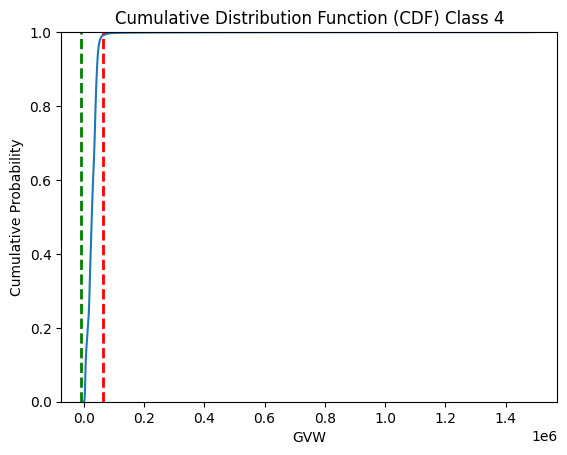

In [330]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.ecdfplot(data=df_sample["gvw"])
plt.title(f'Cumulative Distribution Function (CDF) Class {class_num}')
plt.xlabel('GVW')
plt.ylabel('Cumulative Probability')

plt.axvline(x=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper Bound = {upper_bound}')
plt.axvline(x=lower_bound, color='green', linestyle='--', linewidth=2, label=f'Lower Bound = {lower_bound}')

plt.show()

In [331]:
#Sub-sample for model parameter tuning
sample_size = 10000
tuning_sample_df = df_sample2.sample(sample_size)

In [332]:
#mean , variance similar to complete dataset stats
tuning_sample_df["gvw"].describe()

count    10000.000000
mean     26230.761719
std      13405.391602
min         80.000000
25%      16940.000000
50%      26200.000000
75%      36860.000000
max      63520.000000
Name: gvw, dtype: float64

In [333]:
#Tuning Kmeans n_init parameter for stability
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system
silo_scores_n2 = []
silo_scores_n3 = []
number_of_trials = 50

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_n_init)(tuning_sample_df, cols, n) 
    for n in range(1, number_of_trials+1)
)

# Results are returned in order
for n_init, s2, s3 in results:
    silo_scores_n2.append(s2)
    silo_scores_n3.append(s3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=15)]: Batch computation too fast (0.08899879455566406s.) Setting batch_size=2.
[Parallel(n_jobs=15)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=15)]: Done  12 tasks      | elapsed:    2.0s
[Parallel(n_jobs=15)]: Done  21 tasks      | elapsed:    2.8s
[Parallel(n_jobs=15)]: Done  27 out of  50 | elapsed:    3.0s remaining:    2.5s
[Parallel(n_jobs=15)]: Done  33 out of  50 | elapsed:    3.1s remaining:    1.6s
[Parallel(n_jobs=15)]: Done  39 out of  50 | elapsed:    3.3s remaining:    0.9s
[Parallel(n_jobs=15)]: Done  45 out of  50 | elapsed:    3.5s remaining:    0.3s
[Parallel(n_jobs=15)]: Done  50 out of  50 | elapsed:    3.6s finished


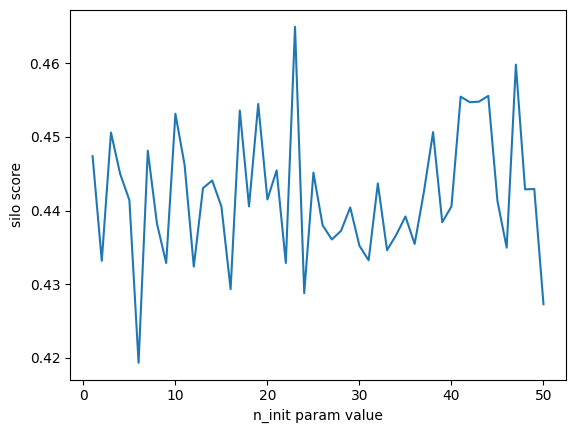

In [334]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,51), silo_scores_n2)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

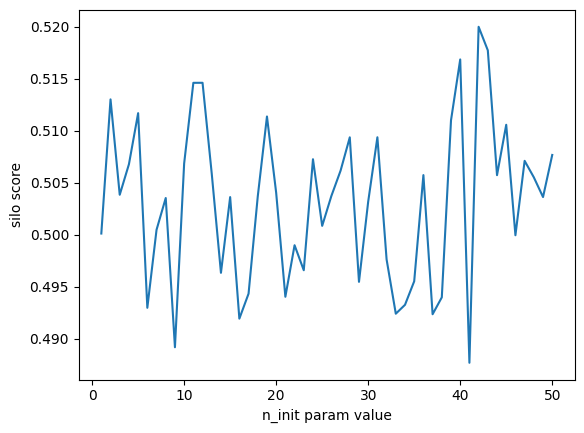

In [335]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,51), silo_scores_n3)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

In [336]:
#remove outliers from sparkdf
df_no_outliers, upper_bound, lower_bound = remove_outliers_iqr2(df_spark, "gvw", iqr_factor)

Upper bound: 63208.0, Lower bound: -9368.0


In [337]:
#Comparing if 2 clusters performs better then 3
cluster_num = 2
n_init_param_cluster2 = 20
number_of_trials = 100
sample_means_silo_scores_n2= [] #sample means cluster num=2

import gc
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 2
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster2) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n2.append(np.mean(silo_score)) #for cluster num = 2
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [338]:
#Comparing if 2 clusters performs better then 3
cluster_num = 3
n_init_param_cluster3 = 20
number_of_trials = 100
sample_means_silo_scores_n3= [] #sample means cluster num = 3

import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 3
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster3) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n3.append(np.mean(silo_score)) #for cluster num = 3
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [339]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(sample_means_silo_scores_n2, sample_means_silo_scores_n3)

print(f"Cluster=2 mean: {np.mean(sample_means_silo_scores_n2):.2f}")
print(f"Cluster=3 mean: {np.mean(sample_means_silo_scores_n3):.2f}")
print(f"Mean difference: {np.mean(sample_means_silo_scores_n3) - np.mean(sample_means_silo_scores_n2):.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

Cluster=2 mean: 0.45
Cluster=3 mean: 0.54
Mean difference: 0.08
T-statistic: -660.608
P-value: 0.0000


In [340]:
print(np.var(sample_means_silo_scores_n2)) 
print(np.var(sample_means_silo_scores_n3))

6.668682310099016e-07
8.410671035257121e-07


In [341]:
#Cluster 2
#Compute the expected silhouette score for the complete data
silo_score_data_sample = 1.0 #data ratio sampled to compute silo score
cols = ["wt1", "wt2"]
result = kmeans_model_spark(df_no_outliers, cols, 2,n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1

0.7492905098377703

In [342]:
#Cluster 3
#Compute the expected silhouette score for the complete data
silo_score_data_sample = 1.0 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 3, n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1


0.6196174379163368

Class 5

In [343]:
import pandas as pd
#filtering by class
class_num = 5
sample_ratio = .01

cols =  [f"wt{i}" for i in range(1, 6)]
df_spark = df5.filter(f"class = {class_num}")

In [344]:
df_spark.select("num_axles").distinct().collect()

[Row(num_axles=3), Row(num_axles=5), Row(num_axles=4), Row(num_axles=2)]

In [345]:
#Sample original dataset
df_sample = df5.filter(f"class = {class_num}").sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

print(f"Number of records {df_sample.count()}")
print(f"Number of records sampled {df_sample.count()*sample_ratio}")

Number of records direction    36965
year         36965
month        36965
day          36965
hour         36965
minute       36965
second       36965
lane         36965
class        36965
speed        36965
num_axles    36965
gvw          36965
wheelbase    36965
wt1          36965
spc1         36965
wt2          36965
spc2         36965
wt3          36965
spc3         36965
wt4          36965
spc4         36965
wt5          36965
spc5         36965
wt6          36965
spc6         36965
wt7          36965
spc7         36965
wt8          36965
spc8         36965
wt9          36965
spc9         36965
wt10         36965
spc10        36965
wt11         36965
spc11        36965
wt12         36965
spc12        36965
wt13         36965
spc13        36965
wt14         36965
spc14        36965
wt15         36965
spc15        36965
wt16         36965
spc16        36965
wt17         36965
dirtravel    36965
yearmonth    36965
date         36965
dtype: int64
Number of records sampled direction   

In [346]:
#Removing outliers from df_sample, removes outliers based off gvw col
iqr_factor = 1.6
df_sample2, upper_bound, lower_bound = remove_outliers_iqr(df_sample, iqr_factor)

#decreased bound size

Outlier Count: 176
Original Count: 36965
Remaining count: 36789
Outlier percentage: 0.48%
Upper bound: 44252.00, Lower bound: -9172.00


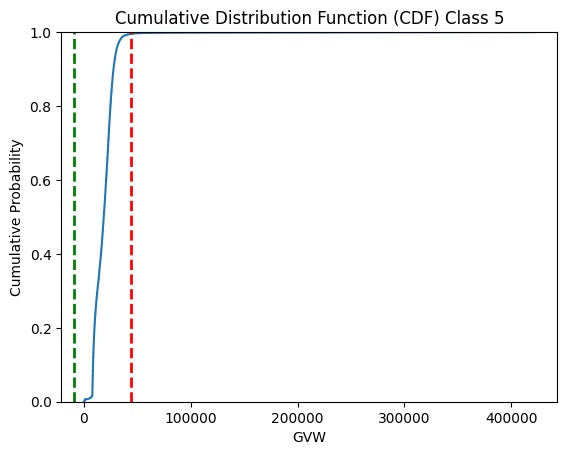

In [347]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.ecdfplot(data=df_sample["gvw"])
plt.title(f'Cumulative Distribution Function (CDF) Class {class_num}')
plt.xlabel('GVW')
plt.ylabel('Cumulative Probability')

plt.axvline(x=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper Bound = {upper_bound}')
plt.axvline(x=lower_bound, color='green', linestyle='--', linewidth=2, label=f'Lower Bound = {lower_bound}')

plt.show()

In [348]:
#Sub-sample for model parameter tuning
sample_size = 10000
tuning_sample_df = df_sample2.sample(sample_size)

In [349]:
#mean , variance similar to complete dataset stats
tuning_sample_df["gvw"].describe()

count    10000.000000
mean     18274.988281
std       7443.668945
min        380.000000
25%      11040.000000
50%      18680.000000
75%      23810.000000
max      44020.000000
Name: gvw, dtype: float64

In [350]:
#Tuning Kmeans n_init parameter for stability
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

silo_scores_n2 = []
silo_scores_n3 = []
number_of_trials = 50

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_n_init)(tuning_sample_df, cols, n) 
    for n in range(1, number_of_trials+1)
)

# Results are returned in order
for n_init, s2, s3 in results:
    silo_scores_n2.append(s2)
    silo_scores_n3.append(s3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Batch computation too fast (0.08843755722045898s.) Setting batch_size=2.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:    0.2s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:    0.4s
[Parallel(n_jobs=15)]: Done  27 out of  50 | elapsed:    0.5s remaining:    0.4s
[Parallel(n_jobs=15)]: Done  33 out of  50 | elapsed:    0.7s remaining:    0.3s
[Parallel(n_jobs=15)]: Done  39 out of  50 | elapsed:    0.9s remaining:    0.2s
[Parallel(n_jobs=15)]: Done  45 out of  50 | elapsed:    1.1s remaining:    0.0s
[Parallel(n_jobs=15)]: Done  50 out of  50 | elapsed:    1.2s finished


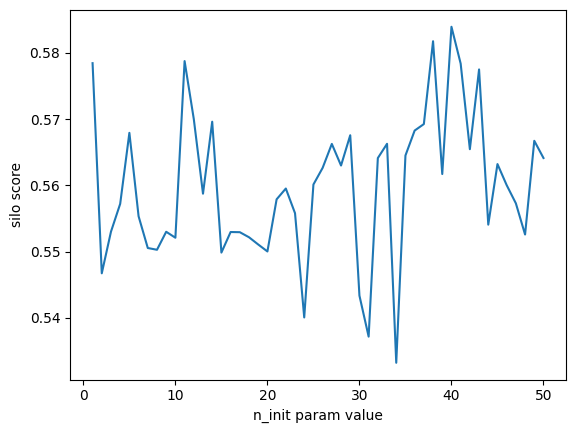

In [351]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,51), silo_scores_n2)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

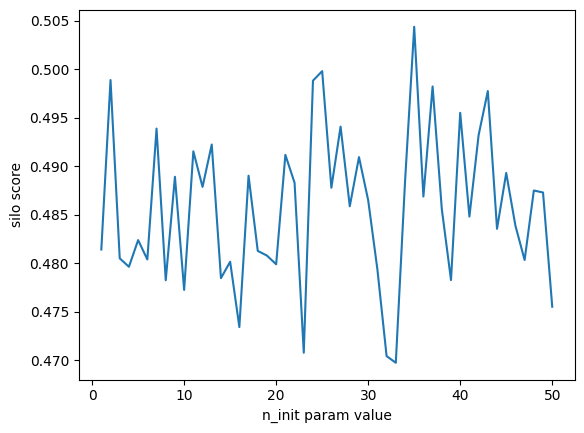

In [352]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,51), silo_scores_n3)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

In [353]:
#remove outliers from sparkdf
df_no_outliers, upper_bound, lower_bound = remove_outliers_iqr2(df_spark, "gvw", iqr_factor)

Upper bound: 44052.0, Lower bound: -9162.0


In [354]:
#Comparing if 2 clusters performs better then 3
cluster_num = 2
n_init_param_cluster2 = 20
number_of_trials = 100
sample_means_silo_scores_n2= [] #sample means cluster num=2

import gc
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 2
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster2) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n2.append(np.mean(silo_score)) #for cluster num = 2
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [355]:
#Comparing if 2 clusters performs better then 3
cluster_num = 3
n_init_param_cluster3 = 20
number_of_trials = 100
sample_means_silo_scores_n3= [] #sample means cluster num = 3

import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 3
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster3) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n3.append(np.mean(silo_score)) #for cluster num = 3
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [356]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(sample_means_silo_scores_n2, sample_means_silo_scores_n3)

print(f"Cluster=2 mean: {np.mean(sample_means_silo_scores_n2):.2f}")
print(f"Cluster=3 mean: {np.mean(sample_means_silo_scores_n3):.2f}")
print(f"Mean difference: {np.mean(sample_means_silo_scores_n3) - np.mean(sample_means_silo_scores_n2):.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

Cluster=2 mean: 0.56
Cluster=3 mean: 0.53
Mean difference: -0.02
T-statistic: 151.049
P-value: 0.0000


In [357]:
print(np.var(sample_means_silo_scores_n2)) 
print(np.var(sample_means_silo_scores_n3))

1.1206942801885446e-06
8.786831925579661e-07


In [358]:
#Cluster 2
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
cols = ["wt1", "wt2"]
result = kmeans_model_spark(df_no_outliers, cols, 2,n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1

0.7426271208564771

In [359]:
#Cluster 3
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
cols = ["wt1", "wt2"]
result = kmeans_model_spark(df_no_outliers, cols, 3, n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1


0.6633344906668467

Class 6

In [360]:
import pandas as pd
#filtering by class
class_num = 6
sample_ratio = .01

cols =  [f"wt{i}" for i in range(1, 6)]
df_spark = df5.filter(f"class = {class_num}")

In [361]:
df_spark.select("num_axles").distinct().collect()

[Row(num_axles=3), Row(num_axles=5), Row(num_axles=4)]

In [362]:
#Sample original dataset
df_sample = df5.filter(f"class = {class_num}").sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

print(f"Number of records {df_sample.count()}")
print(f"Number of records sampled {df_sample.count()*sample_ratio}")

Number of records direction    10943
year         10943
month        10943
day          10943
hour         10943
minute       10943
second       10943
lane         10943
class        10943
speed        10943
num_axles    10943
gvw          10943
wheelbase    10943
wt1          10943
spc1         10943
wt2          10943
spc2         10943
wt3          10943
spc3         10943
wt4          10943
spc4         10943
wt5          10943
spc5         10943
wt6          10943
spc6         10943
wt7          10943
spc7         10943
wt8          10943
spc8         10943
wt9          10943
spc9         10943
wt10         10943
spc10        10943
wt11         10943
spc11        10943
wt12         10943
spc12        10943
wt13         10943
spc13        10943
wt14         10943
spc14        10943
wt15         10943
spc15        10943
wt16         10943
spc16        10943
wt17         10943
dirtravel    10943
yearmonth    10943
date         10943
dtype: int64
Number of records sampled direction   

In [363]:
#Removing outliers from df_sample, removes outliers based off gvw col
iqr_factor = 1.6
df_sample2, upper_bound, lower_bound = remove_outliers_iqr(df_sample, iqr_factor)

#decreased bound size

Outlier Count: 70
Original Count: 10943
Remaining count: 10873
Outlier percentage: 0.64%
Upper bound: 75252.00, Lower bound: -2427.00


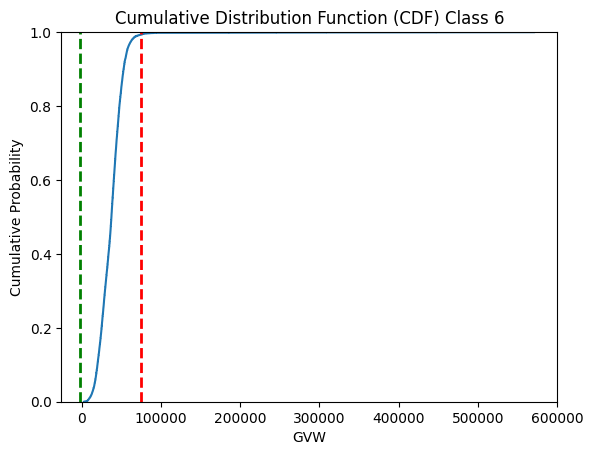

In [364]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.ecdfplot(data=df_sample["gvw"])
plt.title(f'Cumulative Distribution Function (CDF) Class {class_num}')
plt.xlabel('GVW')
plt.ylabel('Cumulative Probability')

plt.axvline(x=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper Bound = {upper_bound}')
plt.axvline(x=lower_bound, color='green', linestyle='--', linewidth=2, label=f'Lower Bound = {lower_bound}')

plt.show()

In [365]:
#Sub-sample for model parameter tuning
sample_size = 10000
tuning_sample_df = df_sample2.sample(sample_size)

In [366]:
#mean , variance similar to complete dataset stats
tuning_sample_df["gvw"].describe()

count    10000.000000
mean     36649.148438
std      12468.436523
min       2620.000000
25%      27160.000000
50%      37390.000000
75%      45485.000000
max      75200.000000
Name: gvw, dtype: float64

In [367]:
#Tuning Kmeans n_init parameter for stability
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

silo_scores_n2 = []
silo_scores_n3 = []
number_of_trials = 50

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_n_init)(tuning_sample_df, cols, n) 
    for n in range(1, number_of_trials+1)
)

# Results are returned in order
for n_init, s2, s3 in results:
    silo_scores_n2.append(s2)
    silo_scores_n3.append(s3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Batch computation too fast (0.09465432167053223s.) Setting batch_size=2.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:    0.2s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:    0.3s
[Parallel(n_jobs=15)]: Done  27 out of  50 | elapsed:    0.5s remaining:    0.4s
[Parallel(n_jobs=15)]: Done  33 out of  50 | elapsed:    0.7s remaining:    0.3s
[Parallel(n_jobs=15)]: Done  39 out of  50 | elapsed:    0.9s remaining:    0.2s
[Parallel(n_jobs=15)]: Done  45 out of  50 | elapsed:    1.0s remaining:    0.0s
[Parallel(n_jobs=15)]: Done  50 out of  50 | elapsed:    1.2s finished


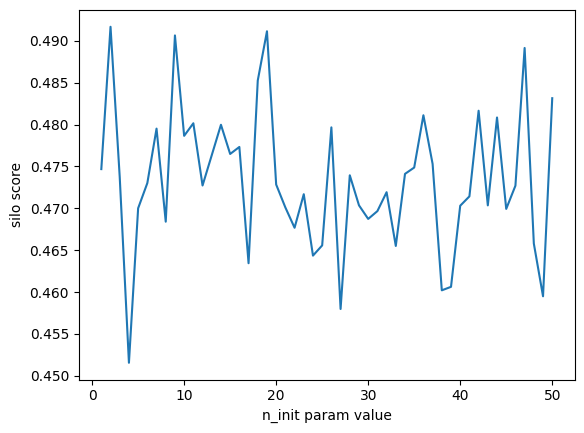

In [368]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,51), silo_scores_n2)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

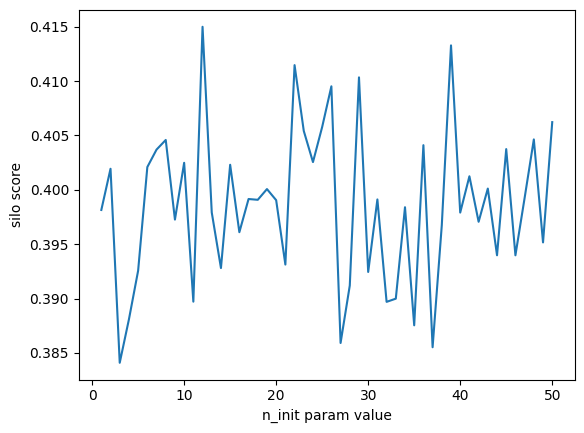

In [369]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,51), silo_scores_n3)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

In [370]:
#remove outliers from sparkdf
df_no_outliers, upper_bound, lower_bound = remove_outliers_iqr2(df_spark, "gvw", iqr_factor)

Upper bound: 74704.0, Lower bound: -2534.0


In [371]:
#Comparing if 2 clusters performs better then 3
cluster_num = 2
n_init_param_cluster2 = 20
number_of_trials = 100
sample_means_silo_scores_n2= [] #sample means cluster num=2

import gc
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 2
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster2) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n2.append(np.mean(silo_score)) #for cluster num = 2
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [372]:
#Comparing if 2 clusters performs better then 3
cluster_num = 3
n_init_param_cluster3 = 20
number_of_trials = 100
sample_means_silo_scores_n3= [] #sample means cluster num = 3

import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 3
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster3) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n3.append(np.mean(silo_score)) #for cluster num = 3
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [373]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(sample_means_silo_scores_n2, sample_means_silo_scores_n3)

print(f"Cluster=2 mean: {np.mean(sample_means_silo_scores_n2):.2f}")
print(f"Cluster=3 mean: {np.mean(sample_means_silo_scores_n3):.2f}")
print(f"Mean difference: {np.mean(sample_means_silo_scores_n3) - np.mean(sample_means_silo_scores_n2):.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

Cluster=2 mean: 0.48
Cluster=3 mean: 0.39
Mean difference: -0.09
T-statistic: 772.791
P-value: 0.0000


In [374]:
print(np.var(sample_means_silo_scores_n2)) 
print(np.var(sample_means_silo_scores_n3))

7.60969138638845e-07
6.441918682886073e-07


In [375]:
#Cluster 2
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 2,n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1

0.6729228502505561

In [376]:
#Cluster 3
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 3, n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1


0.5799479259397047

Class 7

In [377]:
import pandas as pd
#filtering by class
class_num = 7
sample_ratio = 1.0

cols =  [f"wt{i}" for i in range(1, 8)]
df_spark = df5.filter(f"class = {class_num}")

In [378]:
df_spark.select("num_axles").distinct().collect()

[Row(num_axles=6),
 Row(num_axles=5),
 Row(num_axles=4),
 Row(num_axles=7),
 Row(num_axles=3)]

In [379]:
#Sample original dataset
df_sample = df5.filter(f"class = {class_num}").sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

print(f"Number of records {df_sample.count()}")
print(f"Number of records sampled {df_sample.count()*sample_ratio}")

Number of records direction    97931
year         97931
month        97931
day          97931
hour         97931
minute       97931
second       97931
lane         97931
class        97931
speed        97931
num_axles    97931
gvw          97931
wheelbase    97931
wt1          97931
spc1         97931
wt2          97931
spc2         97931
wt3          97931
spc3         97931
wt4          97931
spc4         97931
wt5          97931
spc5         97931
wt6          97931
spc6         97931
wt7          97931
spc7         97931
wt8          97931
spc8         97931
wt9          97931
spc9         97931
wt10         97931
spc10        97931
wt11         97931
spc11        97931
wt12         97931
spc12        97931
wt13         97931
spc13        97931
wt14         97931
spc14        97931
wt15         97931
spc15        97931
wt16         97931
spc16        97931
wt17         97931
dirtravel    97931
yearmonth    97931
date         97931
dtype: int64
Number of records sampled direction   

In [380]:
#Removing outliers from df_sample, removes outliers based off gvw col
iqr_factor = 1.5
df_sample2, upper_bound, lower_bound = remove_outliers_iqr(df_sample, iqr_factor)

#decreased bound size

Outlier Count: 126
Original Count: 97931
Remaining count: 97805
Outlier percentage: 0.13%
Upper bound: 115322.50, Lower bound: -1057.50


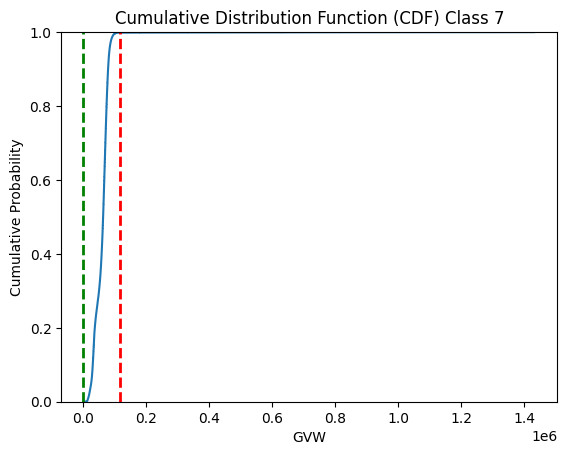

In [381]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.ecdfplot(data=df_sample["gvw"])
plt.title(f'Cumulative Distribution Function (CDF) Class {class_num}')
plt.xlabel('GVW')
plt.ylabel('Cumulative Probability')

plt.axvline(x=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper Bound = {upper_bound}')
plt.axvline(x=lower_bound, color='green', linestyle='--', linewidth=2, label=f'Lower Bound = {lower_bound}')

plt.show()

In [382]:
#Sub-sample for model parameter tuning
sample_size = 10000
tuning_sample_df = df_sample2.sample(sample_size)

In [383]:
#mean , variance similar to complete dataset stats
tuning_sample_df["gvw"].describe()

count     10000.000000
mean      57938.648438
std       18797.828125
min        2520.000000
25%       42752.500000
50%       62860.000000
75%       71662.500000
max      114670.000000
Name: gvw, dtype: float64

In [384]:
#Tuning Kmeans n_init parameter for stability
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

silo_scores_n2 = []
silo_scores_n3 = []
number_of_trials = 50

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_n_init)(tuning_sample_df, cols, n) 
    for n in range(1, number_of_trials+1)
)

# Results are returned in order
for n_init, s2, s3 in results:
    silo_scores_n2.append(s2)
    silo_scores_n3.append(s3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Batch computation too fast (0.09223580360412598s.) Setting batch_size=2.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:    0.2s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:    0.4s
[Parallel(n_jobs=15)]: Done  27 out of  50 | elapsed:    0.5s remaining:    0.4s
[Parallel(n_jobs=15)]: Done  33 out of  50 | elapsed:    0.7s remaining:    0.3s
[Parallel(n_jobs=15)]: Done  39 out of  50 | elapsed:    0.9s remaining:    0.2s
[Parallel(n_jobs=15)]: Done  45 out of  50 | elapsed:    1.1s remaining:    0.0s
[Parallel(n_jobs=15)]: Done  50 out of  50 | elapsed:    1.3s finished


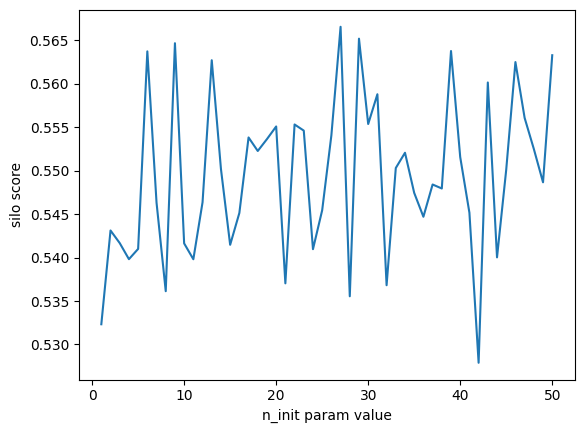

In [385]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,51), silo_scores_n2)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

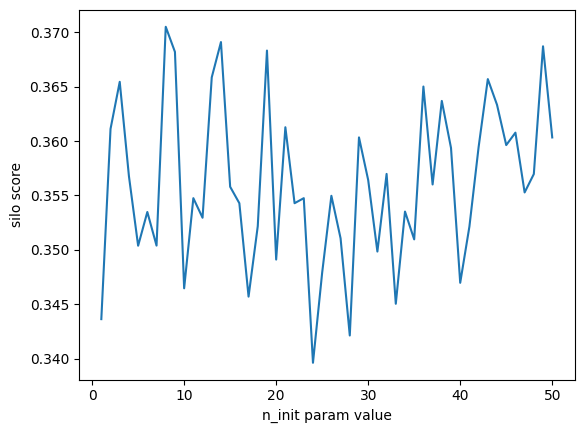

In [386]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,51), silo_scores_n3)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

In [387]:
#remove outliers from sparkdf
df_no_outliers, upper_bound, lower_bound = remove_outliers_iqr2(df_spark, "gvw", iqr_factor)

Upper bound: 115145.0, Lower bound: -1535.0


In [388]:
#Comparing if 2 clusters performs better then 3
cluster_num = 2
n_init_param_cluster2 = 20
number_of_trials = 100
sample_means_silo_scores_n2= [] #sample means cluster num=2

import gc
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 2
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster2) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n2.append(np.mean(silo_score)) #for cluster num = 2
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [389]:
#Comparing if 2 clusters performs better then 3
cluster_num = 3
n_init_param_cluster3 = 20
number_of_trials = 100
sample_means_silo_scores_n3= [] #sample means cluster num = 3

import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 3
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster3) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n3.append(np.mean(silo_score)) #for cluster num = 3
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [390]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(sample_means_silo_scores_n2, sample_means_silo_scores_n3)

print(f"Cluster=2 mean: {np.mean(sample_means_silo_scores_n2):.2f}")
print(f"Cluster=3 mean: {np.mean(sample_means_silo_scores_n3):.2f}")
print(f"Mean difference: {np.mean(sample_means_silo_scores_n3) - np.mean(sample_means_silo_scores_n2):.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

Cluster=2 mean: 0.59
Cluster=3 mean: 0.49
Mean difference: -0.11
T-statistic: 762.165
P-value: 0.0000


In [391]:
print(np.var(sample_means_silo_scores_n2)) 
print(np.var(sample_means_silo_scores_n3))

9.833572493506486e-07
8.968513296686085e-07


In [392]:
#Cluster 2
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 2,n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1

0.7347383665558203

In [393]:
#Cluster 3
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 3, n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1


0.5196093593110409

Class 8

In [394]:
import pandas as pd
#filtering by class
class_num = 8
sample_ratio = 1.0

cols =  [f"wt{i}" for i in range(1, 5)]
df_spark = df5.filter(f"class = {class_num}")

In [395]:
df_spark.select("num_axles").distinct().collect() #mixed set 3 , 4 axles

[Row(num_axles=3), Row(num_axles=4)]

In [396]:
#Sample original dataset
df_sample = df5.filter(f"class = {class_num}").sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

print(f"Number of records {df_sample.count()}")
print(f"Number of records sampled {df_sample.count()*sample_ratio}")

Number of records direction    552164
year         552164
month        552164
day          552164
hour         552164
minute       552164
second       552164
lane         552164
class        552164
speed        552164
num_axles    552164
gvw          552164
wheelbase    552164
wt1          552164
spc1         552164
wt2          552164
spc2         552164
wt3          552164
spc3         552164
wt4          552164
spc4         552164
wt5          552164
spc5         552164
wt6          552164
spc6         552164
wt7          552164
spc7         552164
wt8          552164
spc8         552164
wt9          552164
spc9         552164
wt10         552164
spc10        552164
wt11         552164
spc11        552164
wt12         552164
spc12        552164
wt13         552164
spc13        552164
wt14         552164
spc14        552164
wt15         552164
spc15        552164
wt16         552164
spc16        552164
wt17         552164
dirtravel    552164
yearmonth    552164
date         552164
dt

In [397]:
#Removing outliers from df_sample, removes outliers based off gvw col
iqr_factor = 1.5
df_sample2, upper_bound, lower_bound = remove_outliers_iqr(df_sample, iqr_factor)

#decreased bound size

Outlier Count: 3629
Original Count: 552164
Remaining count: 548535
Outlier percentage: 0.66%
Upper bound: 77250.00, Lower bound: 5810.00


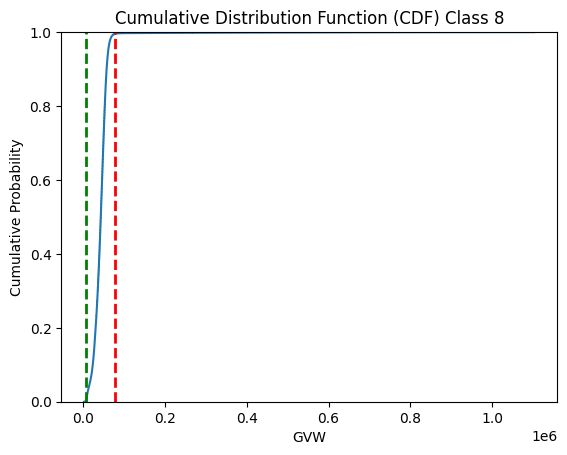

In [398]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.ecdfplot(data=df_sample["gvw"])
plt.title(f'Cumulative Distribution Function (CDF) Class {class_num}')
plt.xlabel('GVW')
plt.ylabel('Cumulative Probability')

plt.axvline(x=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper Bound = {upper_bound}')
plt.axvline(x=lower_bound, color='green', linestyle='--', linewidth=2, label=f'Lower Bound = {lower_bound}')

plt.show()

In [399]:
#Sub-sample for model parameter tuning
sample_size = 10000
tuning_sample_df = df_sample2.sample(sample_size)

In [400]:
#mean , variance similar to complete dataset stats
tuning_sample_df["gvw"].describe()

count    10000.000000
mean     40747.480469
std      13223.181641
min       5860.000000
25%      32580.000000
50%      42320.000000
75%      50170.000000
max      76400.000000
Name: gvw, dtype: float64

In [401]:
#Tuning Kmeans n_init parameter for stability
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

silo_scores_n2 = []
silo_scores_n3 = []
number_of_trials = 50

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_n_init)(tuning_sample_df, cols, n) 
    for n in range(1, number_of_trials+1)
)

# Results are returned in order
for n_init, s2, s3 in results:
    silo_scores_n2.append(s2)
    silo_scores_n3.append(s3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Batch computation too fast (0.07889103889465332s.) Setting batch_size=2.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:    0.3s
[Parallel(n_jobs=15)]: Done  27 out of  50 | elapsed:    0.5s remaining:    0.4s
[Parallel(n_jobs=15)]: Done  33 out of  50 | elapsed:    0.7s remaining:    0.3s
[Parallel(n_jobs=15)]: Done  39 out of  50 | elapsed:    0.8s remaining:    0.2s
[Parallel(n_jobs=15)]: Done  45 out of  50 | elapsed:    1.0s remaining:    0.0s
[Parallel(n_jobs=15)]: Done  50 out of  50 | elapsed:    1.1s finished


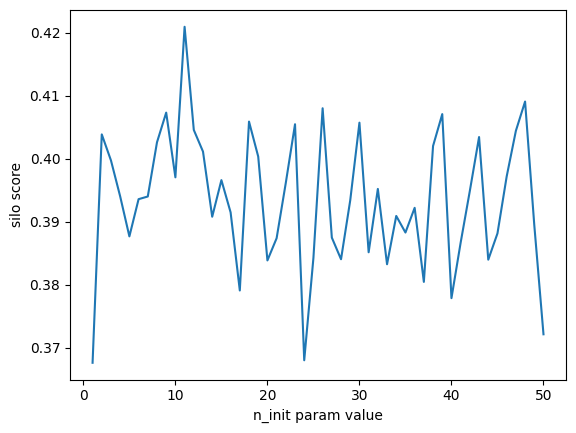

In [402]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,51), silo_scores_n2)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

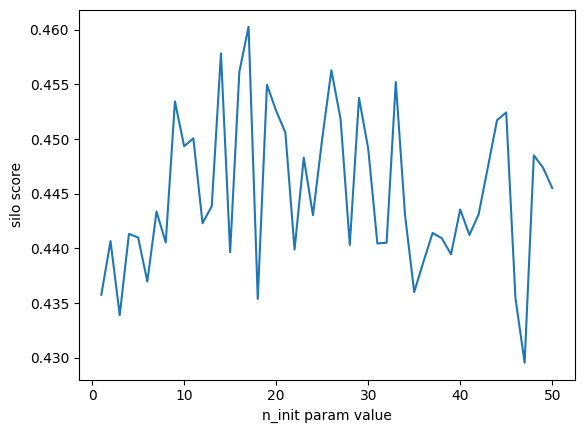

In [403]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,51), silo_scores_n3)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

In [404]:
#remove outliers from sparkdf
df_no_outliers, upper_bound, lower_bound = remove_outliers_iqr2(df_spark, "gvw", iqr_factor)

Upper bound: 76745.0, Lower bound: 5985.0


In [405]:
#Comparing if 2 clusters performs better then 3
cluster_num = 2
n_init_param_cluster2 = 20
number_of_trials = 100
sample_means_silo_scores_n2= [] #sample means cluster num=2

import gc
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 2
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster2) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n2.append(np.mean(silo_score)) #for cluster num = 2
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [406]:
#Comparing if 2 clusters performs better then 3
cluster_num = 3
n_init_param_cluster3 = 20
number_of_trials = 100
sample_means_silo_scores_n3= [] #sample means cluster num = 3

import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 3
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster3) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n3.append(np.mean(silo_score)) #for cluster num = 3
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [407]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(sample_means_silo_scores_n2, sample_means_silo_scores_n3)

print(f"Cluster=2 mean: {np.mean(sample_means_silo_scores_n2):.2f}")
print(f"Cluster=3 mean: {np.mean(sample_means_silo_scores_n3):.2f}")
print(f"Mean difference: {np.mean(sample_means_silo_scores_n3) - np.mean(sample_means_silo_scores_n2):.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

Cluster=2 mean: 0.32
Cluster=3 mean: 0.31
Mean difference: -0.01
T-statistic: 80.711
P-value: 0.0000


In [408]:
print(np.var(sample_means_silo_scores_n2)) 
print(np.var(sample_means_silo_scores_n3))

7.673276220699692e-07
1.0749871653625674e-06


In [409]:
#Cluster 2
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 2,n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1

0.5575769996262595

In [410]:
#Cluster 3
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 3, n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1


0.6306655071788566

Class 9

In [411]:
import pandas as pd
#filtering by class
class_num = 9
sample_ratio = .01

cols =  [f"wt{i}" for i in range(1, 6)]
df_spark = df5.filter(f"class = {class_num}")

In [412]:
df_spark.select("num_axles").distinct().collect() #mixed set 2,3,4,5 axles

[Row(num_axles=5), Row(num_axles=3), Row(num_axles=2), Row(num_axles=4)]

In [413]:
#Sample original dataset
df_sample = df5.filter(f"class = {class_num}").sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

print(f"Number of records {df_sample.count()}")
print(f"Number of records sampled {df_sample.count()*sample_ratio}")

Number of records direction    23153
year         23153
month        23153
day          23153
hour         23153
minute       23153
second       23153
lane         23153
class        23153
speed        23153
num_axles    23153
gvw          23153
wheelbase    23153
wt1          23153
spc1         23153
wt2          23153
spc2         23153
wt3          23153
spc3         23153
wt4          23153
spc4         23153
wt5          23153
spc5         23153
wt6          23153
spc6         23153
wt7          23153
spc7         23153
wt8          23153
spc8         23153
wt9          23153
spc9         23153
wt10         23153
spc10        23153
wt11         23153
spc11        23153
wt12         23153
spc12        23153
wt13         23153
spc13        23153
wt14         23153
spc14        23153
wt15         23153
spc15        23153
wt16         23153
spc16        23153
wt17         23153
dirtravel    23153
yearmonth    23153
date         23153
dtype: int64
Number of records sampled direction   

In [414]:
#Removing outliers from df_sample, removes outliers based off gvw col
iqr_factor = 1.5
df_sample2, upper_bound, lower_bound = remove_outliers_iqr(df_sample, iqr_factor)

#decreased bound size

Outlier Count: 58
Original Count: 23153
Remaining count: 23095
Outlier percentage: 0.25%
Upper bound: 121675.00, Lower bound: -1085.00


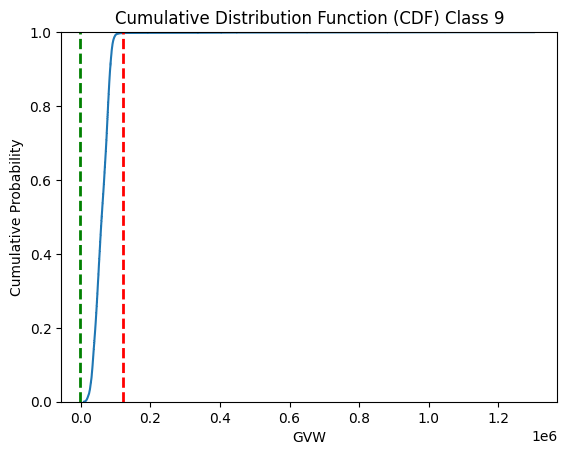

In [415]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.ecdfplot(data=df_sample["gvw"])
plt.title(f'Cumulative Distribution Function (CDF) Class {class_num}')
plt.xlabel('GVW')
plt.ylabel('Cumulative Probability')

plt.axvline(x=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper Bound = {upper_bound}')
plt.axvline(x=lower_bound, color='green', linestyle='--', linewidth=2, label=f'Lower Bound = {lower_bound}')

plt.show()

In [416]:
#Sub-sample for model parameter tuning
sample_size = 10000
tuning_sample_df = df_sample2.sample(sample_size)

In [417]:
#mean , variance similar to complete dataset stats
tuning_sample_df["gvw"].describe()

count     10000.000000
mean      59637.183594
std       19038.398438
min        8520.000000
25%       44850.000000
50%       59730.000000
75%       75500.000000
max      118420.000000
Name: gvw, dtype: float64

In [418]:
#Tuning Kmeans n_init parameter for stability
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

silo_scores_n2 = []
silo_scores_n3 = []
number_of_trials = 50

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_n_init)(tuning_sample_df, cols, n) 
    for n in range(1, number_of_trials+1)
)

# Results are returned in order
for n_init, s2, s3 in results:
    silo_scores_n2.append(s2)
    silo_scores_n3.append(s3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Batch computation too fast (0.0944826602935791s.) Setting batch_size=2.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:    0.2s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:    0.4s
[Parallel(n_jobs=15)]: Done  27 out of  50 | elapsed:    0.5s remaining:    0.5s
[Parallel(n_jobs=15)]: Done  33 out of  50 | elapsed:    0.7s remaining:    0.3s
[Parallel(n_jobs=15)]: Done  39 out of  50 | elapsed:    0.9s remaining:    0.2s
[Parallel(n_jobs=15)]: Done  45 out of  50 | elapsed:    1.0s remaining:    0.0s
[Parallel(n_jobs=15)]: Done  50 out of  50 | elapsed:    1.2s finished


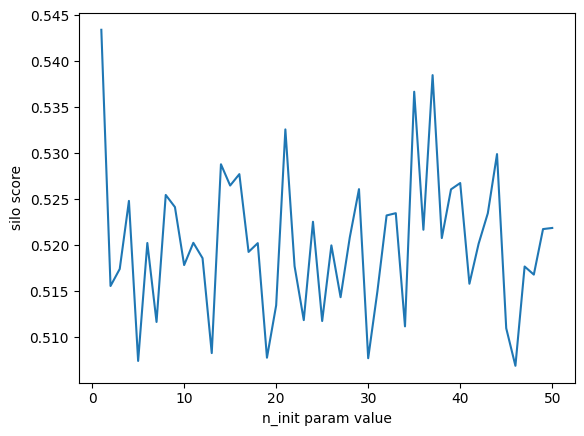

In [419]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,51), silo_scores_n2)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

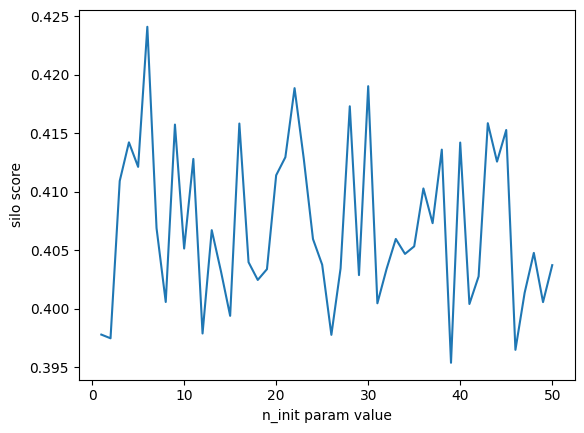

In [420]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,51), silo_scores_n3)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

In [421]:
#remove outliers from sparkdf
df_no_outliers, upper_bound, lower_bound = remove_outliers_iqr2(df_spark, "gvw", iqr_factor)

Upper bound: 121400.0, Lower bound: -1800.0


In [422]:
#Comparing if 2 clusters performs better then 3
cluster_num = 2
n_init_param_cluster2 = 20
number_of_trials = 100
sample_means_silo_scores_n2= [] #sample means cluster num=2

import gc
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 2
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster2) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n2.append(np.mean(silo_score)) #for cluster num = 2
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [423]:
#Comparing if 2 clusters performs better then 3
cluster_num = 3
n_init_param_cluster3 = 20
number_of_trials = 100
sample_means_silo_scores_n3= [] #sample means cluster num = 3

import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 3
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster3) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n3.append(np.mean(silo_score)) #for cluster num = 3
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [424]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(sample_means_silo_scores_n2, sample_means_silo_scores_n3)

print(f"Cluster=2 mean: {np.mean(sample_means_silo_scores_n2):.2f}")
print(f"Cluster=3 mean: {np.mean(sample_means_silo_scores_n3):.2f}")
print(f"Mean difference: {np.mean(sample_means_silo_scores_n3) - np.mean(sample_means_silo_scores_n2):.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

Cluster=2 mean: 0.56
Cluster=3 mean: 0.44
Mean difference: -0.12
T-statistic: 1018.712
P-value: 0.0000


In [425]:
print(np.var(sample_means_silo_scores_n2)) 
print(np.var(sample_means_silo_scores_n3))

6.768839610327848e-07
7.210855081423552e-07


In [426]:
#Cluster 2
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 2,n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1

0.723324063177911

In [427]:
#Cluster 3
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 3, n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1


0.6109824274271609

Class 10

In [428]:
import pandas as pd
#filtering by class
class_num = 10
sample_ratio = 1.0

cols =  [f"wt{i}" for i in range(1, 18)]
df_spark = df5.filter(f"class = {class_num}")

In [429]:
df_spark.select("num_axles").distinct().collect() #mixed set of axles

[Row(num_axles=6),
 Row(num_axles=7),
 Row(num_axles=5),
 Row(num_axles=4),
 Row(num_axles=8),
 Row(num_axles=11),
 Row(num_axles=10),
 Row(num_axles=13),
 Row(num_axles=9),
 Row(num_axles=15),
 Row(num_axles=17),
 Row(num_axles=3)]

In [430]:
#Sample original dataset
df_sample = df5.filter(f"class = {class_num}").sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

print(f"Number of records {df_sample.count()}")
print(f"Number of records sampled {df_sample.count()*sample_ratio}")

Number of records direction    93306
year         93306
month        93306
day          93306
hour         93306
minute       93306
second       93306
lane         93306
class        93306
speed        93306
num_axles    93306
gvw          93306
wheelbase    93306
wt1          93306
spc1         93306
wt2          93306
spc2         93306
wt3          93306
spc3         93306
wt4          93306
spc4         93306
wt5          93306
spc5         93306
wt6          93306
spc6         93306
wt7          93306
spc7         93306
wt8          93306
spc8         93306
wt9          93306
spc9         93306
wt10         93306
spc10        93306
wt11         93306
spc11        93306
wt12         93306
spc12        93306
wt13         93306
spc13        93306
wt14         93306
spc14        93306
wt15         93306
spc15        93306
wt16         93306
spc16        93306
wt17         93306
dirtravel    93306
yearmonth    93306
date         93306
dtype: int64
Number of records sampled direction   

In [431]:
#Removing outliers from df_sample, removes outliers based off gvw col
iqr_factor = 1.5
df_sample2, upper_bound, lower_bound = remove_outliers_iqr(df_sample, iqr_factor)

#decreased bound size

Outlier Count: 240
Original Count: 93306
Remaining count: 93066
Outlier percentage: 0.26%
Upper bound: 176120.00, Lower bound: 3560.00


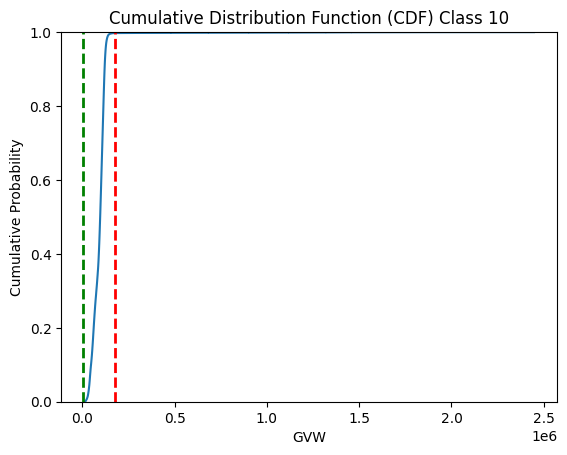

In [432]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.ecdfplot(data=df_sample["gvw"])
plt.title(f'Cumulative Distribution Function (CDF) Class {class_num}')
plt.xlabel('GVW')
plt.ylabel('Cumulative Probability')

plt.axvline(x=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper Bound = {upper_bound}')
plt.axvline(x=lower_bound, color='green', linestyle='--', linewidth=2, label=f'Lower Bound = {lower_bound}')

plt.show()

In [433]:
#Sub-sample for model parameter tuning
sample_size = 10000
tuning_sample_df = df_sample2.sample(sample_size)

In [434]:
#mean , variance similar to complete dataset stats
tuning_sample_df["gvw"].describe()

count     10000.000000
mean      89415.960938
std       28202.330078
min       10020.000000
25%       67507.500000
50%       96365.000000
75%      111162.500000
max      173650.000000
Name: gvw, dtype: float64

In [435]:
#Tuning Kmeans n_init parameter for stability
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

silo_scores_n2 = []
silo_scores_n3 = []
number_of_trials = 50

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_n_init)(tuning_sample_df, cols, n) 
    for n in range(1, number_of_trials+1)
)

# Results are returned in order
for n_init, s2, s3 in results:
    silo_scores_n2.append(s2)
    silo_scores_n3.append(s3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Batch computation too fast (0.12711596488952637s.) Setting batch_size=2.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:    0.2s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:    0.5s
[Parallel(n_jobs=15)]: Done  27 out of  50 | elapsed:    0.8s remaining:    0.6s
[Parallel(n_jobs=15)]: Done  33 out of  50 | elapsed:    1.0s remaining:    0.5s
[Parallel(n_jobs=15)]: Done  39 out of  50 | elapsed:    1.2s remaining:    0.3s
[Parallel(n_jobs=15)]: Done  45 out of  50 | elapsed:    1.4s remaining:    0.1s
[Parallel(n_jobs=15)]: Done  50 out of  50 | elapsed:    1.6s finished


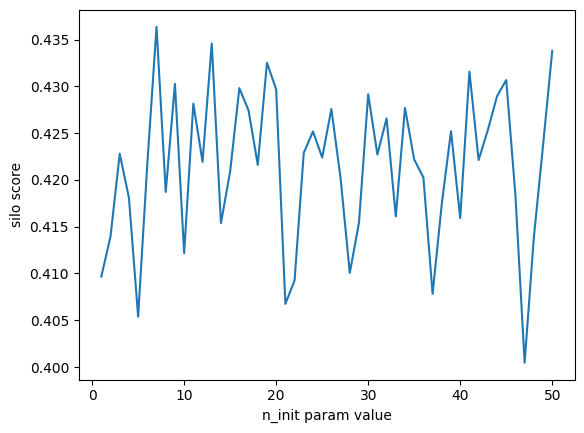

In [436]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,51), silo_scores_n2)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

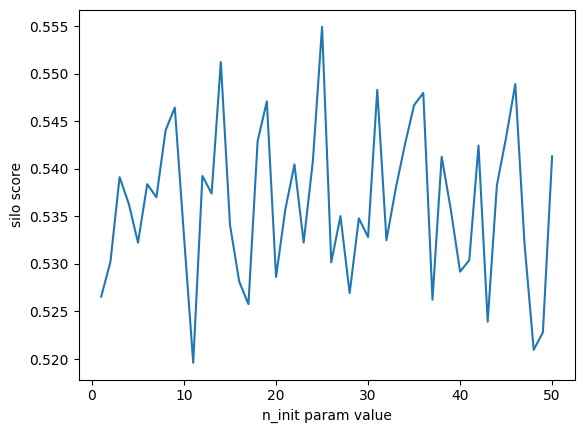

In [437]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,51), silo_scores_n3)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

In [438]:
#remove outliers from sparkdf
df_no_outliers, upper_bound, lower_bound = remove_outliers_iqr2(df_spark, "gvw", iqr_factor)

Upper bound: 175600.0, Lower bound: 3280.0


In [439]:
#Comparing if 2 clusters performs better then 3
cluster_num = 2
n_init_param_cluster2 = 20
number_of_trials = 100
sample_means_silo_scores_n2= [] #sample means cluster num=2

import gc
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 2
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster2) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n2.append(np.mean(silo_score)) #for cluster num = 2
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [440]:
#Comparing if 2 clusters performs better then 3
cluster_num = 3
n_init_param_cluster3 = 20
number_of_trials = 100
sample_means_silo_scores_n3= [] #sample means cluster num = 3

import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 3
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster3) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n3.append(np.mean(silo_score)) #for cluster num = 3
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [441]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(sample_means_silo_scores_n2, sample_means_silo_scores_n3)

print(f"Cluster=2 mean: {np.mean(sample_means_silo_scores_n2):.2f}")
print(f"Cluster=3 mean: {np.mean(sample_means_silo_scores_n3):.2f}")
print(f"Mean difference: {np.mean(sample_means_silo_scores_n3) - np.mean(sample_means_silo_scores_n2):.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

Cluster=2 mean: 0.48
Cluster=3 mean: 0.51
Mean difference: 0.03
T-statistic: -268.329
P-value: 0.0000


In [442]:
print(np.var(sample_means_silo_scores_n2)) 
print(np.var(sample_means_silo_scores_n3))

9.202379904040505e-07
7.624321792882541e-07


In [443]:
#Cluster 2
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 2,n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1

0.5845895992917122

In [444]:
#Cluster 3
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 3, n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1


0.7350854416120756

Class 11

In [445]:
import pandas as pd
#filtering by class
class_num = 11
sample_ratio = 1.0

cols =  [f"wt{i}" for i in range(1, 6)]
df_spark = df5.filter(f"class = {class_num}")

In [446]:
df_spark.select("num_axles").distinct().collect() 

[Row(num_axles=5)]

In [447]:
#Sample original dataset
df_sample = df5.filter(f"class = {class_num}").sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

print(f"Number of records {df_sample.count()}")
print(f"Number of records sampled {df_sample.count()*sample_ratio}")

Number of records direction    70407
year         70407
month        70407
day          70407
hour         70407
minute       70407
second       70407
lane         70407
class        70407
speed        70407
num_axles    70407
gvw          70407
wheelbase    70407
wt1          70407
spc1         70407
wt2          70407
spc2         70407
wt3          70407
spc3         70407
wt4          70407
spc4         70407
wt5          70407
spc5         70407
wt6          70407
spc6         70407
wt7          70407
spc7         70407
wt8          70407
spc8         70407
wt9          70407
spc9         70407
wt10         70407
spc10        70407
wt11         70407
spc11        70407
wt12         70407
spc12        70407
wt13         70407
spc13        70407
wt14         70407
spc14        70407
wt15         70407
spc15        70407
wt16         70407
spc16        70407
wt17         70407
dirtravel    70407
yearmonth    70407
date         70407
dtype: int64
Number of records sampled direction   

In [448]:
#Removing outliers from df_sample, removes outliers based off gvw col
iqr_factor = 1.7
df_sample2, upper_bound, lower_bound = remove_outliers_iqr(df_sample, iqr_factor)

#decreased bound size

Outlier Count: 1092
Original Count: 70407
Remaining count: 69315
Outlier percentage: 1.55%
Upper bound: 109628.00, Lower bound: 20572.00


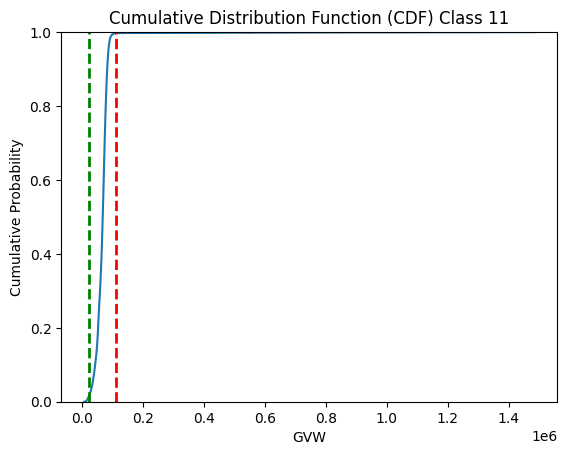

In [449]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.ecdfplot(data=df_sample["gvw"])
plt.title(f'Cumulative Distribution Function (CDF) Class {class_num}')
plt.xlabel('GVW')
plt.ylabel('Cumulative Probability')

plt.axvline(x=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper Bound = {upper_bound}')
plt.axvline(x=lower_bound, color='green', linestyle='--', linewidth=2, label=f'Lower Bound = {lower_bound}')

plt.show()

In [450]:
#Sub-sample for model parameter tuning
sample_size = 10000
tuning_sample_df = df_sample2.sample(sample_size)

In [451]:
#mean , variance similar to complete dataset stats
tuning_sample_df["gvw"].describe()

count     10000.000000
mean      65024.492188
std       14902.790039
min       20600.000000
25%       55750.000000
50%       67600.000000
75%       75332.500000
max      109180.000000
Name: gvw, dtype: float64

In [452]:
#Tuning Kmeans n_init parameter for stability
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

silo_scores_n2 = []
silo_scores_n3 = []
number_of_trials = 50

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_n_init)(tuning_sample_df, cols, n) 
    for n in range(1, number_of_trials+1)
)

# Results are returned in order
for n_init, s2, s3 in results:
    silo_scores_n2.append(s2)
    silo_scores_n3.append(s3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Batch computation too fast (0.10766887664794922s.) Setting batch_size=2.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:    0.2s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:    0.4s
[Parallel(n_jobs=15)]: Done  27 out of  50 | elapsed:    0.6s remaining:    0.5s
[Parallel(n_jobs=15)]: Done  33 out of  50 | elapsed:    0.9s remaining:    0.4s
[Parallel(n_jobs=15)]: Done  39 out of  50 | elapsed:    1.1s remaining:    0.3s
[Parallel(n_jobs=15)]: Done  45 out of  50 | elapsed:    1.3s remaining:    0.1s
[Parallel(n_jobs=15)]: Done  50 out of  50 | elapsed:    1.6s finished


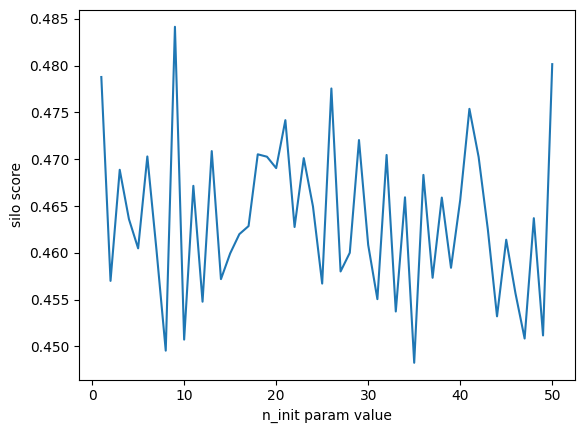

In [453]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,51), silo_scores_n2)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

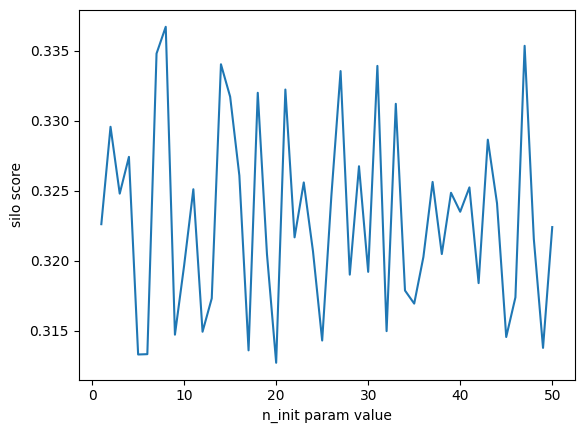

In [454]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,51), silo_scores_n3)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

In [455]:
#remove outliers from sparkdf
df_no_outliers, upper_bound, lower_bound = remove_outliers_iqr2(df_spark, "gvw", iqr_factor)

Upper bound: 109110.0, Lower bound: 20670.0


In [456]:
#Comparing if 2 clusters performs better then 3
cluster_num = 2
n_init_param_cluster2 = 20
number_of_trials = 100
sample_means_silo_scores_n2= [] #sample means cluster num=2

import gc
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 2
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster2) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n2.append(np.mean(silo_score)) #for cluster num = 2
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [457]:
#Comparing if 2 clusters performs better then 3
cluster_num = 3
n_init_param_cluster3 = 20
number_of_trials = 100
sample_means_silo_scores_n3= [] #sample means cluster num = 3

import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 3
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster3) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n3.append(np.mean(silo_score)) #for cluster num = 3
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [458]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(sample_means_silo_scores_n2, sample_means_silo_scores_n3)

print(f"Cluster=2 mean: {np.mean(sample_means_silo_scores_n2):.2f}")
print(f"Cluster=3 mean: {np.mean(sample_means_silo_scores_n3):.2f}")
print(f"Mean difference: {np.mean(sample_means_silo_scores_n3) - np.mean(sample_means_silo_scores_n2):.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

Cluster=2 mean: 0.39
Cluster=3 mean: 0.33
Mean difference: -0.06
T-statistic: 529.409
P-value: 0.0000


In [459]:
print(np.var(sample_means_silo_scores_n2)) 
print(np.var(sample_means_silo_scores_n3))

5.726820992569463e-07
5.635222610080554e-07


In [460]:
#Cluster 2
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 2,n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1

0.6569278132390881

In [461]:
#Cluster 3
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 3, n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1


0.5015238919959031

Class 12

In [462]:
import pandas as pd
#filtering by class
class_num = 12
sample_ratio = 1.0

cols =  [f"wt{i}" for i in range(1, 7)]
df_spark = df5.filter(f"class = {class_num}")

In [463]:
df_spark.select("num_axles").distinct().collect() 

[Row(num_axles=6), Row(num_axles=4), Row(num_axles=5)]

In [464]:
#Sample original dataset
df_sample = df5.filter(f"class = {class_num}").sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

print(f"Number of records {df_sample.count()}")
print(f"Number of records sampled {df_sample.count()*sample_ratio}")

Number of records direction    32837
year         32837
month        32837
day          32837
hour         32837
minute       32837
second       32837
lane         32837
class        32837
speed        32837
num_axles    32837
gvw          32837
wheelbase    32837
wt1          32837
spc1         32837
wt2          32837
spc2         32837
wt3          32837
spc3         32837
wt4          32837
spc4         32837
wt5          32837
spc5         32837
wt6          32837
spc6         32837
wt7          32837
spc7         32837
wt8          32837
spc8         32837
wt9          32837
spc9         32837
wt10         32837
spc10        32837
wt11         32837
spc11        32837
wt12         32837
spc12        32837
wt13         32837
spc13        32837
wt14         32837
spc14        32837
wt15         32837
spc15        32837
wt16         32837
spc16        32837
wt17         32837
dirtravel    32837
yearmonth    32837
date         32837
dtype: int64
Number of records sampled direction   

In [465]:
#Removing outliers from df_sample, removes outliers based off gvw col
iqr_factor = 2.0
df_sample2, upper_bound, lower_bound = remove_outliers_iqr(df_sample, iqr_factor)

#decreased bound size

Outlier Count: 551
Original Count: 32837
Remaining count: 32286
Outlier percentage: 1.68%
Upper bound: 100360.00, Lower bound: 20460.00


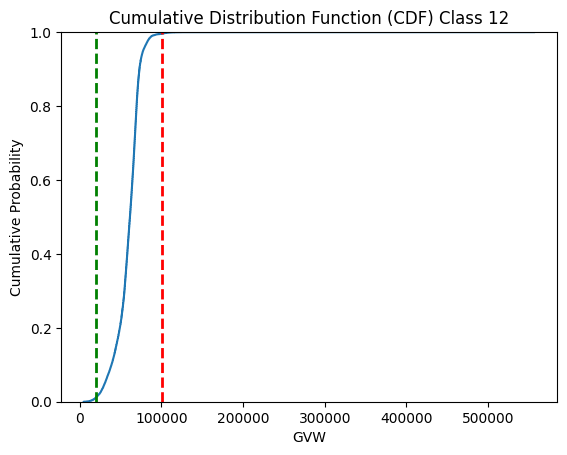

In [466]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.ecdfplot(data=df_sample["gvw"])
plt.title(f'Cumulative Distribution Function (CDF) Class {class_num}')
plt.xlabel('GVW')
plt.ylabel('Cumulative Probability')

plt.axvline(x=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper Bound = {upper_bound}')
plt.axvline(x=lower_bound, color='green', linestyle='--', linewidth=2, label=f'Lower Bound = {lower_bound}')

plt.show()

In [467]:
#Sub-sample for model parameter tuning
sample_size = 10000
tuning_sample_df = df_sample2.sample(sample_size)

In [468]:
#mean , variance similar to complete dataset stats
tuning_sample_df["gvw"].describe()

count     10000.000000
mean      59673.562500
std       12916.979492
min       20460.000000
25%       53215.000000
50%       61840.000000
75%       68460.000000
max      100210.000000
Name: gvw, dtype: float64

In [469]:
#Tuning Kmeans n_init parameter for stability
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

silo_scores_n2 = []
silo_scores_n3 = []
number_of_trials = 50

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_n_init)(tuning_sample_df, cols, n) 
    for n in range(1, number_of_trials+1)
)

# Results are returned in order
for n_init, s2, s3 in results:
    silo_scores_n2.append(s2)
    silo_scores_n3.append(s3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Batch computation too fast (0.09096455574035645s.) Setting batch_size=2.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:    0.2s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:    0.4s
[Parallel(n_jobs=15)]: Done  27 out of  50 | elapsed:    0.6s remaining:    0.5s
[Parallel(n_jobs=15)]: Done  33 out of  50 | elapsed:    0.8s remaining:    0.3s
[Parallel(n_jobs=15)]: Done  39 out of  50 | elapsed:    0.9s remaining:    0.2s
[Parallel(n_jobs=15)]: Done  45 out of  50 | elapsed:    1.1s remaining:    0.0s
[Parallel(n_jobs=15)]: Done  50 out of  50 | elapsed:    1.3s finished


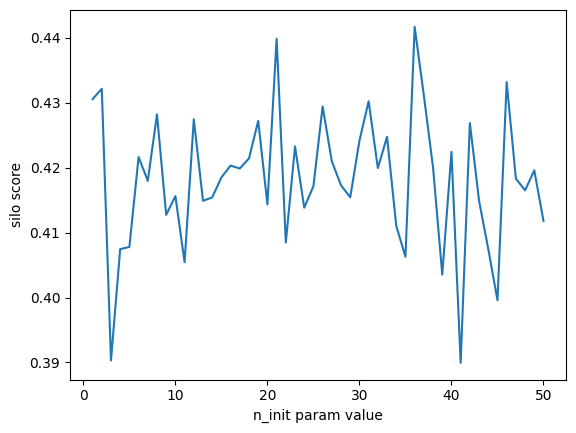

In [470]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,51), silo_scores_n2)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

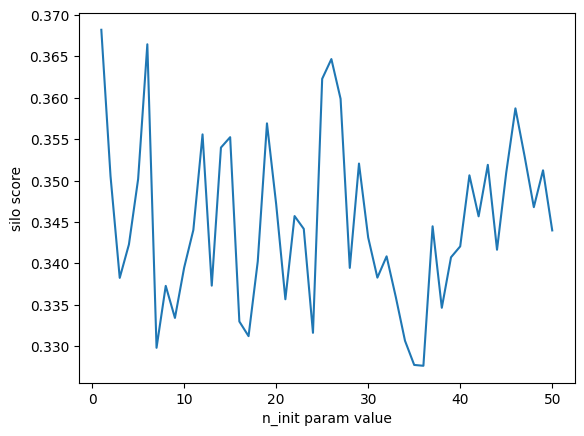

In [471]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,51), silo_scores_n3)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

In [472]:
#remove outliers from sparkdf
df_no_outliers, upper_bound, lower_bound = remove_outliers_iqr2(df_spark, "gvw", iqr_factor)

Upper bound: 100380.0, Lower bound: 19980.0


In [ ]:
#Comparing if 2 clusters performs better then 3
cluster_num = 2
n_init_param_cluster2 = 20
number_of_trials = 100
sample_means_silo_scores_n2= [] #sample means cluster num=2

import gc
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 2
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster2) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n2.append(np.mean(silo_score)) #for cluster num = 2
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [ ]:
#Comparing if 2 clusters performs better then 3
cluster_num = 3
n_init_param_cluster3 = 20
number_of_trials = 100
sample_means_silo_scores_n3= [] #sample means cluster num = 3

import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 3
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster3) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n3.append(np.mean(silo_score)) #for cluster num = 3
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [ ]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(sample_means_silo_scores_n2, sample_means_silo_scores_n3)

print(f"Cluster=2 mean: {np.mean(sample_means_silo_scores_n2):.2f}")
print(f"Cluster=3 mean: {np.mean(sample_means_silo_scores_n3):.2f}")
print(f"Mean difference: {np.mean(sample_means_silo_scores_n3) - np.mean(sample_means_silo_scores_n2):.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

Cluster=2 mean: 0.64
Cluster=3 mean: 0.39
Mean difference: -0.26
T-statistic: 2104.797
P-value: 0.0000


In [ ]:
print(np.var(sample_means_silo_scores_n2)) 
print(np.var(sample_means_silo_scores_n3))

6.84691456835326e-07
7.814733130888048e-07


In [ ]:
#Cluster 2
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 2,n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1

0.818053607624938

In [ ]:
#Cluster 3
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 3, n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1


0.5043837843741368

Class 13

In [103]:
import pandas as pd
#filtering by class
class_num = 13
sample_ratio = 1.0

cols = [f"wt{i}" for i in range(1, 6)]
df_spark = df5.filter(f"class = {class_num}")

In [95]:
df_spark.select("num_axles").distinct().collect() 

[Row(num_axles=9),
 Row(num_axles=8),
 Row(num_axles=7),
 Row(num_axles=10),
 Row(num_axles=16),
 Row(num_axles=22),
 Row(num_axles=23),
 Row(num_axles=11),
 Row(num_axles=20),
 Row(num_axles=6),
 Row(num_axles=3),
 Row(num_axles=5),
 Row(num_axles=4),
 Row(num_axles=13),
 Row(num_axles=2),
 Row(num_axles=15),
 Row(num_axles=12),
 Row(num_axles=17),
 Row(num_axles=14)]

In [104]:
#Sample original dataset
df_sample = df5.filter(f"class = {class_num}").sample(
    withReplacement=False,  
    fraction=sample_ratio,           
    seed=42                 
).toPandas()

print(f"Number of records {df_sample.count()}")
print(f"Number of records sampled {df_sample.count()*sample_ratio}")

Number of records direction    6765
year         6765
month        6765
day          6765
hour         6765
minute       6765
second       6765
lane         6765
class        6765
speed        6765
num_axles    6765
gvw          6765
wheelbase    6765
wt1          6765
spc1         6765
wt2          6765
spc2         6765
wt3          6765
spc3         6765
wt4          6765
spc4         6765
wt5          6765
spc5         6765
wt6          6765
spc6         6765
wt7          6765
spc7         6765
wt8          6765
spc8         6765
wt9          6765
spc9         6765
wt10         6765
spc10        6765
wt11         6765
spc11        6765
wt12         6765
spc12        6765
wt13         6765
spc13        6765
wt14         6765
spc14        6765
wt15         6765
spc15        6765
wt16         6765
spc16        6765
wt17         6765
dirtravel    6765
yearmonth    6765
date         6765
dtype: int64
Number of records sampled direction    6765.0
year         6765.0
month        6765.0
d

In [93]:
for col in cols:
    zero_count = (df_sample2[col] == 0).sum()
    print(f"Column {col}: {zero_count} zeros")

Column wt1: 5 zeros
Column wt2: 0 zeros
Column wt3: 3 zeros
Column wt4: 7 zeros
Column wt5: 11 zeros
Column wt6: 4069 zeros
Column wt7: 4608 zeros
Column wt8: 6137 zeros
Column wt9: 6480 zeros
Column wt10: 6610 zeros
Column wt11: 6672 zeros
Column wt12: 6699 zeros
Column wt13: 6714 zeros
Column wt14: 6718 zeros
Column wt15: 6723 zeros
Column wt16: 6725 zeros
Column wt17: 6728 zeros


In [99]:
#Removing outliers from df_sample, removes outliers based off gvw col
iqr_factor = 1.5
df_sample2, upper_bound, lower_bound = remove_outliers_iqr(df_sample, iqr_factor)

#decreased bound size

Outlier Count: 32
Original Count: 6765
Remaining count: 6733
Outlier percentage: 0.47%
Upper bound: 166670.00, Lower bound: -55970.00


In [62]:
df_sample2.describe()

,year,month,day,hour,minute,second,lane,class,speed,num_axles,...,spc13,wt14,spc14,wt15,spc15,wt16,spc16,wt17,dirtravel,yearmonth
count,6733.000000,6733.000000,6733.000000,6733.000000,6733.000000,6733.000000,6733.000000,6733.0,6733.000000,6733.000000,...,6733.000000,6733.000000,6733.000000,6733.000000,6733.000000,6733.000000,6733.00000,6733.000000,6733.000000,6733.000000
mean,20.960939,6.549681,16.295262,10.337888,29.949799,28.735333,2.368038,13.0,46.817912,5.877321,...,0.036432,10.112877,0.026244,6.032972,0.019100,4.466063,0.01705,2.725382,0.007901,202102.643547
std,1.181704,3.518406,8.807010,5.787563,17.354492,17.203651,0.640299,0.0,458.383141,1.351517,...,0.977078,236.537434,0.792727,172.481944,0.666888,146.055995,0.67259,109.891705,0.451152,116.895827
min,19.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,13.0,1.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,201910.000000
25%,20.000000,4.000000,9.000000,6.000000,15.000000,14.000000,2.000000,13.0,24.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,202007.000000
50%,21.000000,7.000000,17.000000,9.000000,30.000000,29.000000,2.000000,13.0,30.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,202105.000000
75%,22.000000,9.000000,24.000000,14.000000,45.000000,44.000000,3.000000,13.0,42.000000,7.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,202204.000000
max,25.000000,12.000000,31.000000,23.000000,59.000000,59.000000,3.000000,13.0,18837.000000,23.000000,...,43.700000,9080.000000,37.800000,8460.000000,34.100000,7020.000000,34.10000,6840.000000,34.600000,202503.000000


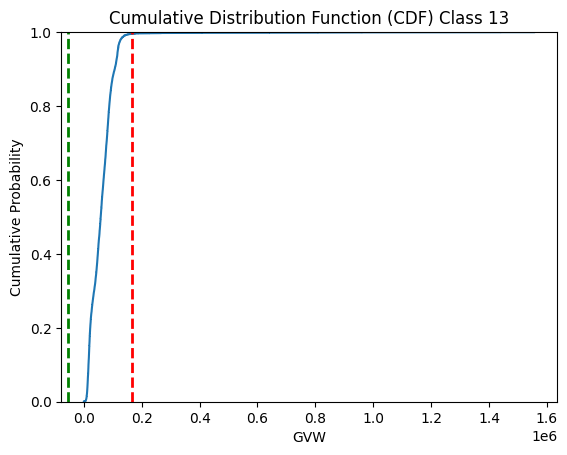

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.ecdfplot(data=df_sample["gvw"])
plt.title(f'Cumulative Distribution Function (CDF) Class {class_num}')
plt.xlabel('GVW')
plt.ylabel('Cumulative Probability')

plt.axvline(x=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper Bound = {upper_bound}')
plt.axvline(x=lower_bound, color='green', linestyle='--', linewidth=2, label=f'Lower Bound = {lower_bound}')

plt.show()

In [45]:
result = kmeans_model_pandas(df_sample2, cols, 2, 20)

result["silhouette"]

np.float64(0.9921297071394285)

In [105]:
silo_scores_n2 = []
silo_scores_n3 = []
for i in range(1,51):
    result = tune_n_init(df_sample2,cols, i)
    silo_scores_n2.append(result[1])
    silo_scores_n3.append(result[2])

0.9898485686547829
2
0.9893429633624937
3
0.9938086477271836
2
0.98829807817831
3
0.9889815369246203
2
0.9897472016573147
3
0.9923107527270523
2
0.9938889525759648
3
0.9887422412893946
2
0.9928857556738669
3
0.9943506408075204
3
0.9946915584902934
2
0.9918375727301885
3
0.9938552856180972
2
0.9929199673088026
2
0.9886080300107131
2
0.9948332914798069
3
0.9938228638313388
3
0.9936447571567971
3
0.9895277669783736
3
0.9928517941390514
3
0.9887475187228133
2
0.9938553241214306
3
0.9926342259582324
2
0.989430728638853
3
0.9944007598859402
3
0.9899296246715981
2
0.9927708611005888
3
0.9938877804686214
2
0.9946865817008614
3
0.9914402601424533
3
0.9927781542043258
3
0.99277433022644
3
0.9932564923992002
3
0.9906378320993887
2
0.9938488235127111
3
0.9937891366966524
2
0.9882729781130165
3
0.9938159764118097
3
0.9907603250403237
2
0.9895932091715408
2
0.9898861875641646
2
0.9881384913924887
2
0.9863173856718208
3


In [85]:
len(silo_scores_n2)

50

In [ ]:
silo_scores_n2 

#Might have to use another metric to evaluate class 13
#Silhouette score is producing invalid results for some trials, may be zero in the demoninator

[nan,
 np.float64(0.9926364202333519),
 nan,
 np.float64(0.9912582035942118),
 nan,
 np.float64(0.9931722758497954),
 nan,
 nan,
 np.float64(0.9909452925742687),
 np.float64(0.9920779972768028),
 np.float64(0.9864400546232576),
 nan,
 np.float64(0.9935833539507161),
 nan,
 nan,
 nan,
 nan,
 nan,
 np.float64(0.9893555061373084),
 np.float64(0.9932232874062442),
 np.float64(0.9916130924429261),
 nan,
 np.float64(0.992697275790985),
 np.float64(0.9913448215081457),
 np.float64(0.9924870865485284),
 nan,
 nan,
 np.float64(0.9924415250271919),
 nan,
 np.float64(0.9926899942902171),
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 np.float64(0.9880600833961853),
 nan,
 nan,
 nan,
 nan,
 nan,
 np.float64(0.9925011664605515),
 np.float64(0.9931355716491601),
 np.float64(0.9886011671734598),
 np.float64(0.9907137171681397),
 np.float64(0.9927264332799297),
 nan,
 np.float64(0.9914828545392631),
 nan]

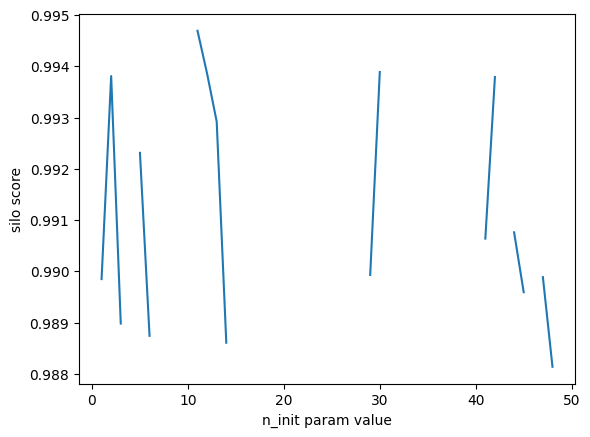

In [106]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,51), silo_scores_n2)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

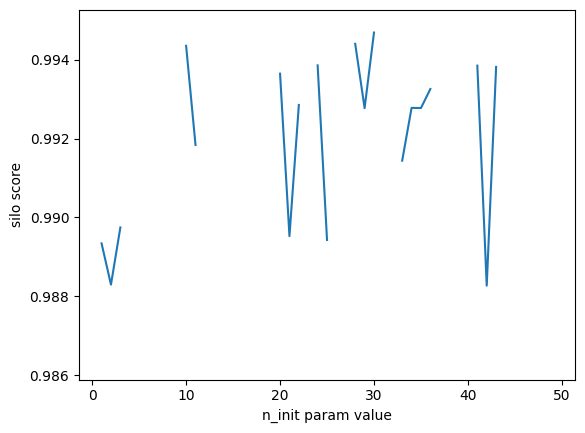

In [107]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,51), silo_scores_n3)
plt.xlabel("n_init param value")
plt.ylabel("silo score")
plt.show()

In [89]:
#remove outliers from sparkdf
df_no_outliers, upper_bound, lower_bound = remove_outliers_iqr2(df_spark, "gvw", iqr_factor)

Upper bound: 165375.0, Lower bound: -55945.0


In [90]:
#Comparing if 2 clusters performs better then 3
cluster_num = 2
n_init_param_cluster2 = 20
number_of_trials = 100
sample_means_silo_scores_n2= [] #sample means cluster num=2

import gc
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 2
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster2) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n2.append(np.mean(silo_score)) #for cluster num = 2
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100


ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "c:\Users\rubie\anaconda3\envs\Fall25_Capstone\Lib\site-packages\py4j\java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\rubie\anaconda3\envs\Fall25_Capstone\Lib\site-packages\py4j\clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\rubie\anaconda3\envs\Fall25_Capstone\Lib\socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [ ]:
#Comparing if 2 clusters performs better then 3
cluster_num = 3
n_init_param_cluster3 = 20
number_of_trials = 100
sample_means_silo_scores_n3= [] #sample means cluster num = 3

import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 3
for i in range(1,number_of_trials+1):
    df_sample = df_no_outliers.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(10000) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(kmeans_model_pandas)(df_sample, cols, cluster_num, n_init_param_cluster3) 
        for n in range(1, number_of_trials+1)
    )

    silo_score = []
    # Results are returned in order
    for info in results:
        silo_score.append(info["silhouette"])

    sample_means_silo_scores_n3.append(np.mean(silo_score)) #for cluster num = 3
    print(f"Sample mean computed {i}/{number_of_trials}")

    del df_sample, results, silo_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [ ]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(sample_means_silo_scores_n2, sample_means_silo_scores_n3)

print(f"Cluster=2 mean: {np.mean(sample_means_silo_scores_n2):.2f}")
print(f"Cluster=3 mean: {np.mean(sample_means_silo_scores_n3):.2f}")
print(f"Mean difference: {np.mean(sample_means_silo_scores_n3) - np.mean(sample_means_silo_scores_n2):.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

Cluster=2 mean: 0.50
Cluster=3 mean: 0.51
Mean difference: 0.01
T-statistic: -52.242
P-value: 0.0000


In [ ]:
print(np.var(sample_means_silo_scores_n2)) 
print(np.var(sample_means_silo_scores_n3))

6.96805226315726e-07
8.432223847332146e-07


In [ ]:
#Cluster 2
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 2,n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1

0.6986621734947783

In [ ]:
#Cluster 3
#Compute the expected silhouette score for the complete data
silo_score_data_sample = .1 #data ratio sampled to compute silo score
result = kmeans_model_spark(df_no_outliers, cols, 3, n_init=None, sample_fraction=silo_score_data_sample)
result["silhouette"] #range -1 to 1


0.6343681151044566